# 📊 The Complete Matplotlib Tutorial
### From Foundations to Real-World Data Visualization

## 👤 Author

**Name:** Muhammad Usman  
**GitHub:** [@MuhammadUsman0005](https://github.com/MuhammadUsman0005)  
**LinkedIn:** [@muhammad-usman-256364398](https://linkedin.com/in/muhammad-usman-256364398)

> **Library:** Matplotlib 3.x  
> **Difficulty:** Beginner → Advanced  
> **Time to Complete:** ~3–4 hours

---

## 📚 Table of Contents

### PART 1 — Foundations
1. [Setup & Imports](#setup)
2. [Figure & Axes Anatomy — The Mental Model](#anatomy)
3. [Line Plots — Trends & Time Series](#line)
4. [Scatter Plots — Relationships & Correlations](#scatter)
5. [Bar Charts — Comparisons](#bar)
6. [Histograms — Distributions](#histogram)
7. [Pie & Donut Charts](#pie)

### PART 2 — Intermediate
8. [Subplots — Multiple Panels in One Figure](#subplots)
9. [Colors, Styles & Themes](#styles)
10. [Annotations, Text & Arrows](#annotations)
11. [Twin Axes — Dual Y-Axis](#twinx)
12. [Box Plots & Violin Plots — Statistical Summaries](#boxplot)

### PART 3 — Advanced & Practical Applications
13. [Heatmaps — Correlation & Confusion Matrices](#heatmap)
14. [Filled Area & Stacked Charts](#area)
15. [Real-World Sales Dashboard](#dashboard)
16. [Saving Figures for Reports & Presentations](#saving)
17. [Key Takeaways & Cheat Sheet](#summary)

---

## Why Matplotlib?

Matplotlib is the **foundation of all Python data visualization**. Libraries like Seaborn, Pandas `.plot()`, and even parts of Plotly are built on top of it. Mastering Matplotlib means you can:

- Create **any** chart type imaginable
- Have **pixel-level control** over every visual element
- Build **publication-quality** figures for papers, reports, and dashboards
- Understand what every higher-level library is doing under the hood

The key insight: Matplotlib follows an **object-oriented model** — once you understand Figure and Axes objects, everything else clicks into place. 🚀


---
# PART 1 — Foundations
---

<a id='setup'></a>
## 1. Setup & Imports


In [1]:
# ─────────────────────────────────────────────────────────────
# IMPORTS — put ALL imports at the top so readers know
# exactly what is required before running the notebook.
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt   # The main pyplot interface — 'plt' is universal alias
import matplotlib.patches as mpatches  # For custom legend handles & shapes
import numpy as np                # For generating sample data and math operations
import pandas as pd               # For real-world tabular data examples

# Tell Jupyter to render plots directly inside the notebook
%matplotlib inline

# ── Global style settings ─────────────────────────────────
# rcParams = "runtime configuration parameters"
# These apply to EVERY plot in the notebook unless overridden locally.
# Think of it as the notebook's global CSS.
plt.rcParams['figure.dpi']       = 120        # Higher DPI = sharper images
plt.rcParams['figure.figsize']   = (9, 5)     # Default figure size in inches (width, height)
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False      # Remove top border for cleaner look
plt.rcParams['axes.spines.right']= False      # Remove right border
plt.rcParams['axes.grid']        = True       # Show gridlines by default
plt.rcParams['grid.alpha']       = 0.35       # Make gridlines subtle
plt.rcParams['grid.linestyle']   = '--'

import matplotlib
print(f"Matplotlib version : {matplotlib.__version__}")
print(f"NumPy      version : {np.__version__}")
print(f"Pandas     version : {pd.__version__}")
print("Setup complete! ✅")


Matplotlib version : 3.10.8
NumPy      version : 2.4.4
Pandas     version : 3.0.2
Setup complete! ✅


<a id='anatomy'></a>
## 2. Figure & Axes Anatomy — The Mental Model

This is the **single most important concept** in Matplotlib. Everything else builds on it.

### The Two Objects You Must Know

| Object | What it is | Analogy |
|--------|-----------|---------|
| **`Figure`** | The entire canvas/window | A picture frame |
| **`Axes`** | The actual plot area inside the Figure | The canvas inside the frame |

A single Figure can contain **multiple Axes** (subplots). Each Axes has its own x-axis, y-axis, title, and data.

### Two Ways to Use Matplotlib

**1. pyplot (functional) style** — quick, one-liner plots:
```python
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Quick plot")
plt.show()
```

**2. Object-Oriented (OO) style** — full control, recommended for anything non-trivial:
```python
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("OO style")
plt.show()
```

**Always prefer the OO style** — it makes subplots, customization, and code reuse far easier.


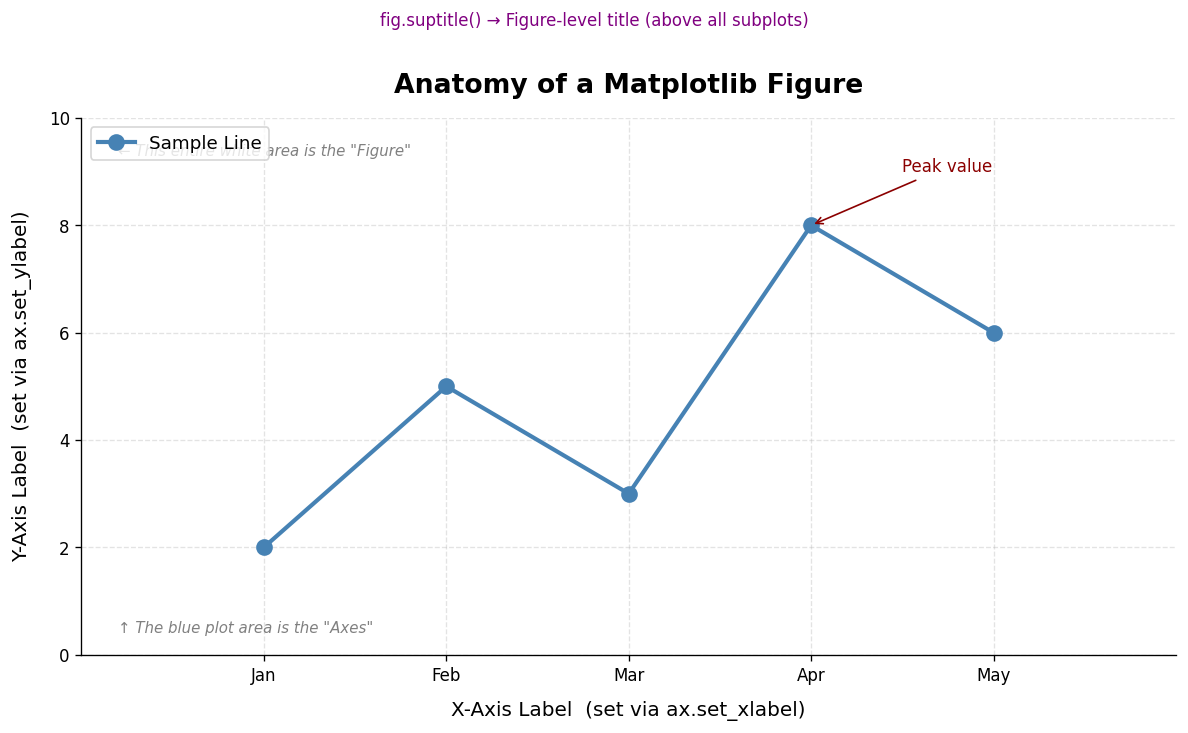

In [2]:
# ── Visualising the Figure / Axes anatomy ────────────────────
# We draw a labeled diagram showing the key components of a Matplotlib figure.
# Read the labels — they map directly to the API you'll use every day.

fig, ax = plt.subplots(figsize=(10, 6))   # Create 1 Figure with 1 Axes

# ── Sample data ───────────────────────────────────────────
x = [1, 2, 3, 4, 5]
y = [2, 5, 3, 8, 6]

# ── Plot the data ─────────────────────────────────────────
ax.plot(x, y,
        color='steelblue',      # Line color
        linewidth=2.5,          # Line thickness
        marker='o',             # Show a circle at each data point
        markersize=9,           # Size of the marker
        label='Sample Line')    # Label used in the legend

# ── Title & axis labels — the most basic annotations ──────
# ax.set_title   → text above the plot
# ax.set_xlabel  → text below the x-axis
# ax.set_ylabel  → text left of the y-axis
ax.set_title('Anatomy of a Matplotlib Figure',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('X-Axis Label  (set via ax.set_xlabel)',
              fontsize=12, labelpad=10)
ax.set_ylabel('Y-Axis Label  (set via ax.set_ylabel)',
              fontsize=12, labelpad=10)

# ── Axis limits — control what range is visible ───────────
ax.set_xlim(0, 6)     # x-axis from 0 to 6
ax.set_ylim(0, 10)    # y-axis from 0 to 10

# ── Tick customization ─────────────────────────────────────
ax.set_xticks([1, 2, 3, 4, 5])                  # Where to place ticks
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May'])  # Labels for each tick
ax.tick_params(axis='both', labelsize=10)        # Tick label font size

# ── Legend — automatically uses 'label=' from each plot call
ax.legend(loc='upper left', fontsize=11)   # loc controls position

# ── Annotate a specific point with an arrow ───────────────
ax.annotate('Peak value',
            xy=(4, 8),            # Arrow tip (data coordinates)
            xytext=(4.5, 9),      # Text position
            fontsize=10,
            color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

# ── Add a text note anywhere on the figure ────────────────
ax.text(0.2, 9.3,
        '← This entire white area is the "Figure"',
        fontsize=9, color='gray', style='italic')

ax.text(0.2, 0.4,
        '↑ The blue plot area is the "Axes"',
        fontsize=9, color='gray', style='italic')

# Figure-level title (different from axes title — sits above everything)
fig.suptitle('fig.suptitle() → Figure-level title (above all subplots)',
             fontsize=10, color='purple', y=1.01)

plt.tight_layout()   # Automatically adjusts spacing so nothing overlaps
plt.show()


<a id='line'></a>
## 3. Line Plots — Trends & Time Series

Line plots are the **go-to for showing change over time** or any ordered sequence. They answer questions like: "How did sales grow over 12 months?" or "How does temperature change throughout the day?"

### When to use a line plot
- Data has a natural order (time, sequence number, distance)
- You want to show **trends**, **rises**, or **falls**
- Comparing multiple series over the same x-axis


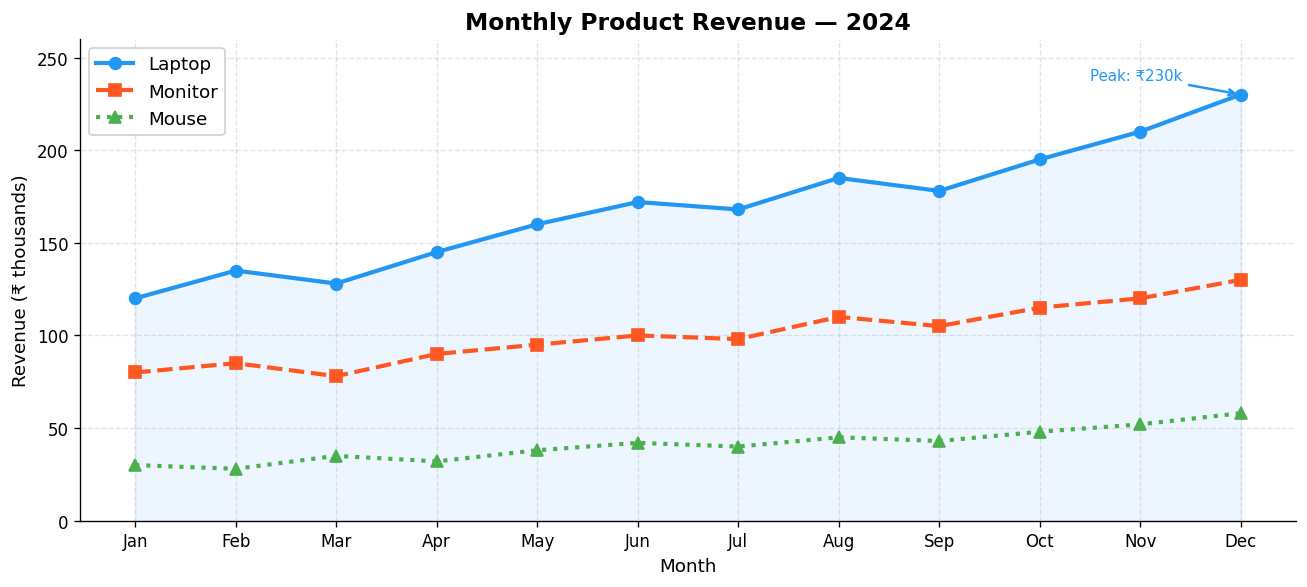

In [3]:
# ── Dataset: Monthly revenue for 3 products over 1 year ──────
np.random.seed(42)     # seed = reproducible random numbers every run

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))   # [0, 1, 2, ..., 11] — numeric positions

# Simulated monthly revenue (in thousands)
laptop  = [120, 135, 128, 145, 160, 172, 168, 185, 178, 195, 210, 230]
monitor = [ 80,  85,  78,  90,  95, 100,  98, 110, 105, 115, 120, 130]
mouse   = [ 30,  28,  35,  32,  38,  42,  40,  45,  43,  48,  52,  58]

fig, ax = plt.subplots(figsize=(11, 5))

# ── Plot three lines — each with distinct style ───────────
# marker=   shapes: 'o' circle, 's' square, '^' triangle, 'D' diamond
# linestyle: '-' solid, '--' dashed, ':' dotted, '-.' dash-dot
ax.plot(x, laptop,  color='#2196F3', linewidth=2.5,
        marker='o', markersize=7, label='Laptop')
ax.plot(x, monitor, color='#FF5722', linewidth=2.5,
        marker='s', markersize=7, label='Monitor', linestyle='--')
ax.plot(x, mouse,   color='#4CAF50', linewidth=2.5,
        marker='^', markersize=7, label='Mouse',   linestyle=':')

# ── Shade the area under the Laptop line ──────────────────
# fill_between() draws a filled region between two y-values.
# alpha= controls transparency (0=invisible, 1=opaque)
ax.fill_between(x, laptop, alpha=0.08, color='#2196F3')

# ── Axis labels & tick customization ──────────────────────
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=10)
ax.set_ylabel('Revenue (₹ thousands)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Monthly Product Revenue — 2024', fontsize=14, fontweight='bold')

# ── Add the peak value as a text annotation ───────────────
peak_idx = np.argmax(laptop)   # index of the maximum value
ax.annotate(f'Peak: ₹{laptop[peak_idx]}k',
            xy=(peak_idx, laptop[peak_idx]),
            xytext=(peak_idx - 1.5, laptop[peak_idx] + 8),
            fontsize=9, color='#2196F3',
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5))

# ── Legend — place it in best available spot ──────────────
# loc='best' lets Matplotlib find the least-cluttered position
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 260)

plt.tight_layout()
plt.show()


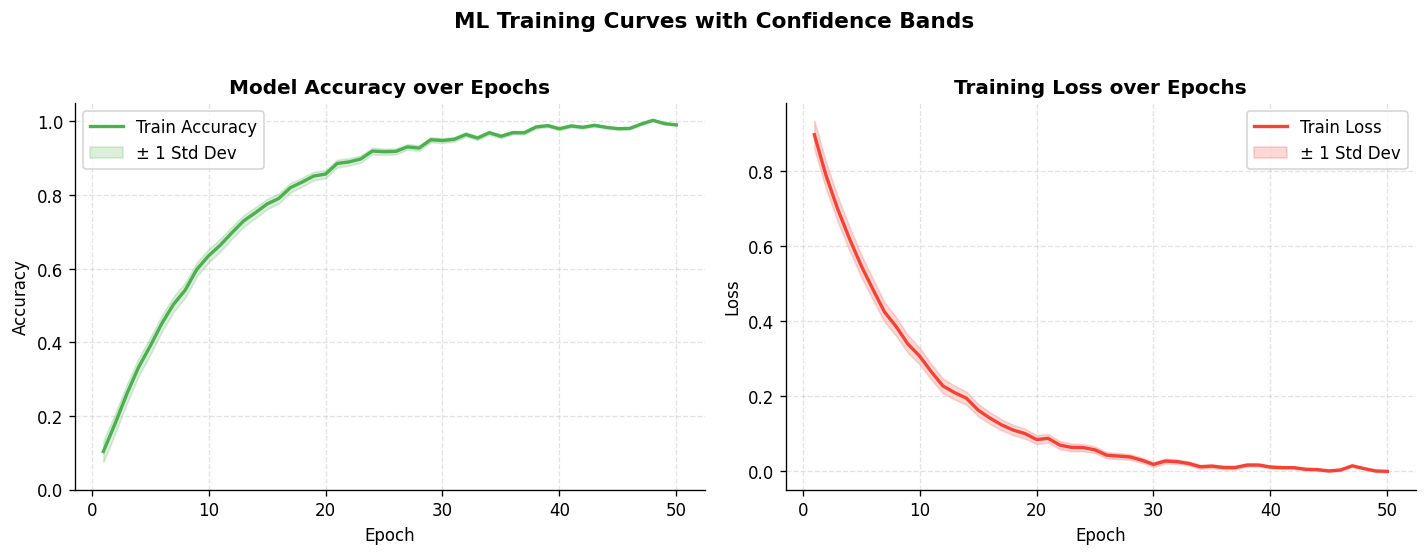

In [4]:
# ── Advanced Line: Plot with confidence interval (shaded band) ──
# Very common in ML/statistics: show mean ± std deviation as a band.
# This pattern appears in training-loss curves, A/B test results, etc.

np.random.seed(7)
epochs = np.arange(1, 51)    # Training epochs 1..50

# Simulate mean accuracy and its standard deviation
mean_acc = 1 - np.exp(-0.1 * epochs) + np.random.normal(0, 0.005, 50)
std_acc  = 0.03 * np.exp(-0.05 * epochs)    # band narrows as training stabilises

mean_loss = np.exp(-0.12 * epochs) + np.random.normal(0, 0.005, 50)
std_loss  = 0.04 * np.exp(-0.06 * epochs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left panel: Accuracy ──────────────────────────────────
ax1.plot(epochs, mean_acc, color='#4CAF50', lw=2, label='Train Accuracy')
# fill_between with mean ± std creates the confidence band
ax1.fill_between(epochs,
                 mean_acc - std_acc,
                 mean_acc + std_acc,
                 alpha=0.2, color='#4CAF50', label='± 1 Std Dev')
ax1.set_title('Model Accuracy over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_ylim(0, 1.05)

# ── Right panel: Loss ─────────────────────────────────────
ax2.plot(epochs, mean_loss, color='#F44336', lw=2, label='Train Loss')
ax2.fill_between(epochs,
                 mean_loss - std_loss,
                 mean_loss + std_loss,
                 alpha=0.2, color='#F44336', label='± 1 Std Dev')
ax2.set_title('Training Loss over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# fig.suptitle adds one shared title above BOTH subplots
fig.suptitle('ML Training Curves with Confidence Bands',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


<a id='scatter'></a>
## 4. Scatter Plots — Relationships & Correlations

Scatter plots show the **relationship between two numerical variables**. Each point represents one observation. They answer: "Is there a pattern between X and Y?"

### When to use scatter plots
- Exploring **correlation** between two variables
- Identifying **clusters** or **outliers**
- Visualizing the output of classification or regression models
- Adding a 3rd dimension via **color** or **size** of points


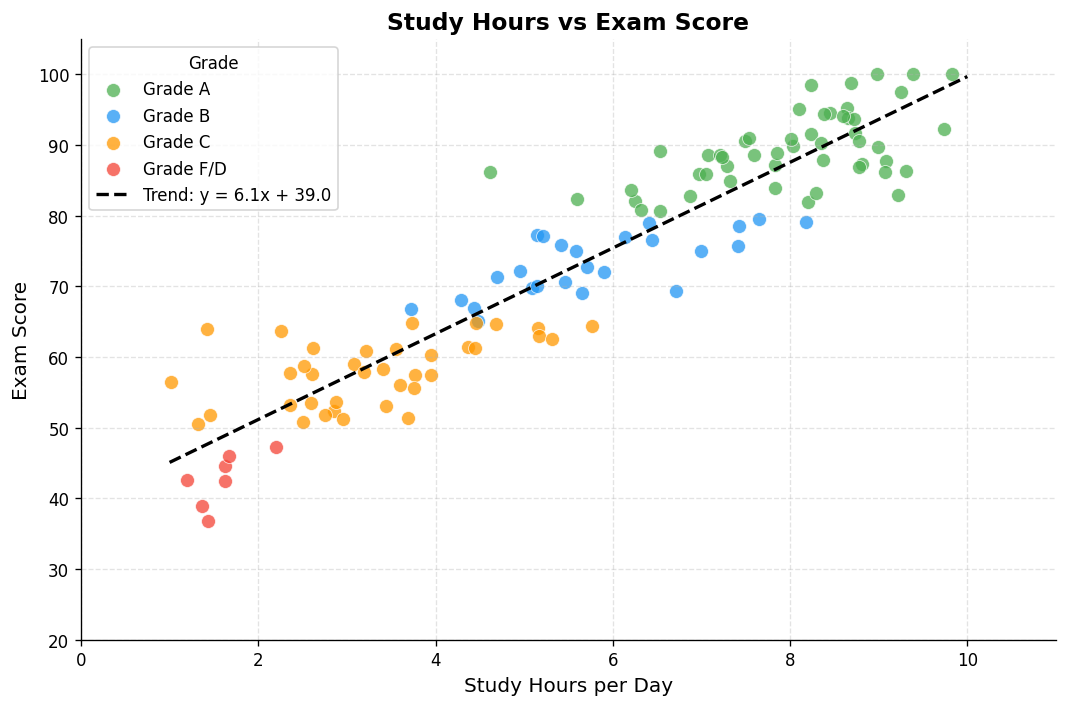

In [5]:
# ── Dataset: Student study hours vs exam scores ───────────────
np.random.seed(21)
n = 120

study_hours = np.random.uniform(1, 10, n)
# Score increases with study hours, plus some random noise
exam_score  = 40 + 6 * study_hours + np.random.normal(0, 6, n)
exam_score  = np.clip(exam_score, 0, 100)   # keep scores in 0–100 range

# Grade based on score — will be used for COLOR grouping
grades = pd.cut(exam_score,
                bins=[0, 50, 65, 80, 100],
                labels=['F/D', 'C', 'B', 'A'])

grade_colors = {'A': '#4CAF50', 'B': '#2196F3', 'C': '#FF9800', 'F/D': '#F44336'}

fig, ax = plt.subplots(figsize=(9, 6))

# ── Plot each grade group in a different color ────────────
# Splitting by group and plotting separately gives us a proper legend
for grade, color in grade_colors.items():
    mask = grades == grade
    ax.scatter(study_hours[mask], exam_score[mask],
               c=color,
               s=70,            # s= controls marker SIZE (area in points²)
               alpha=0.75,      # slight transparency prevents overlapping dots from hiding each other
               edgecolors='white',  # thin white border makes individual points pop
               linewidths=0.5,
               label=f'Grade {grade}')

# ── Trend line (linear regression) ───────────────────────
# np.polyfit fits a polynomial; degree=1 gives a straight line (y = mx + b)
# np.polyval evaluates the polynomial at given x values
m, b = np.polyfit(study_hours, exam_score, 1)   # returns (slope, intercept)
x_line = np.linspace(1, 10, 100)
ax.plot(x_line, m * x_line + b,
        color='black', lw=2, linestyle='--',
        label=f'Trend: y = {m:.1f}x + {b:.1f}', zorder=5)
# zorder= controls drawing order — higher = drawn on top

ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Exam Score', fontsize=12)
ax.set_title('Study Hours vs Exam Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, title='Grade', title_fontsize=10)
ax.set_xlim(0, 11)
ax.set_ylim(20, 105)

plt.tight_layout()
plt.show()


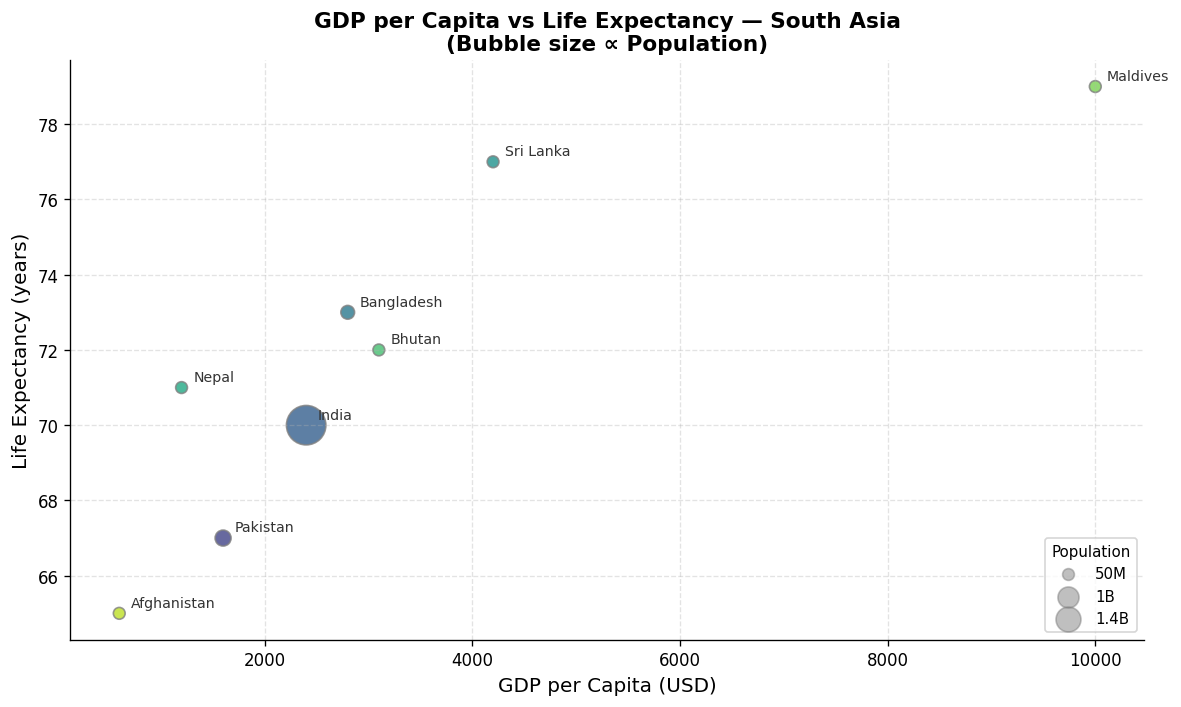

In [6]:
# ── Bubble Chart: Scatter where SIZE encodes a 3rd variable ──
# A bubble chart is just scatter() with s= mapped to a data column.
# Great for showing 3 variables at once (x, y, bubble size).

np.random.seed(5)
countries = ['Pakistan', 'India', 'Bangladesh', 'Sri Lanka',
             'Nepal',    'Bhutan', 'Maldives',  'Afghanistan']

gdp_per_capita = [1600, 2400, 2800, 4200, 1200, 3100, 10000, 600]
life_expectancy= [67,   70,   73,   77,   71,   72,    79,   65]
population_M   = [230, 1400,  170,   22,   30,    1,    0.5,  40]  # millions

fig, ax = plt.subplots(figsize=(10, 6))

# ── Bubble size scaled from population ───────────────────
# We multiply by 0.4 to keep bubbles a reasonable visual size.
# The scaling factor is aesthetic — adjust until it looks right.
bubble_sizes = [p * 0.4 for p in population_M]
# min size is capped at 50 so small countries remain visible
bubble_sizes = [max(s, 50) for s in bubble_sizes]

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(countries)))  # colormap → list of RGBA colors

scatter = ax.scatter(gdp_per_capita, life_expectancy,
                     s=bubble_sizes,
                     c=colors,
                     alpha=0.8,
                     edgecolors='gray',
                     linewidths=1)

# ── Label each bubble with the country name ───────────────
for i, country in enumerate(countries):
    ax.annotate(country,
                xy=(gdp_per_capita[i], life_expectancy[i]),
                xytext=(7, 4),           # offset in points from the dot
                textcoords='offset points',
                fontsize=8.5, color='#333')

# ── Bubble size legend (manual) ───────────────────────────
# Matplotlib doesn't auto-generate size legends, so we create proxy handles manually
for pop, label in [(50, '50M'), (400, '1B'), (560, '1.4B')]:
    ax.scatter([], [], s=max(pop * 0.4, 50), c='gray', alpha=0.5, label=label)

ax.set_xlabel('GDP per Capita (USD)', fontsize=12)
ax.set_ylabel('Life Expectancy (years)', fontsize=12)
ax.set_title('GDP per Capita vs Life Expectancy — South Asia\n(Bubble size ∝ Population)',
             fontsize=13, fontweight='bold')
ax.legend(title='Population', fontsize=9, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


<a id='bar'></a>
## 5. Bar Charts — Comparisons

Bar charts are the **most common chart type for comparing discrete categories**. They answer: "Which category is largest?" or "How do groups compare?"

### Horizontal vs Vertical
- **Vertical** (`ax.bar`) — use when category names are short and you want to emphasize magnitude
- **Horizontal** (`ax.barh`) — use when category names are long, or there are many categories

### Key variants
- **Grouped bars** — compare multiple series side by side
- **Stacked bars** — show part-to-whole relationship within each category


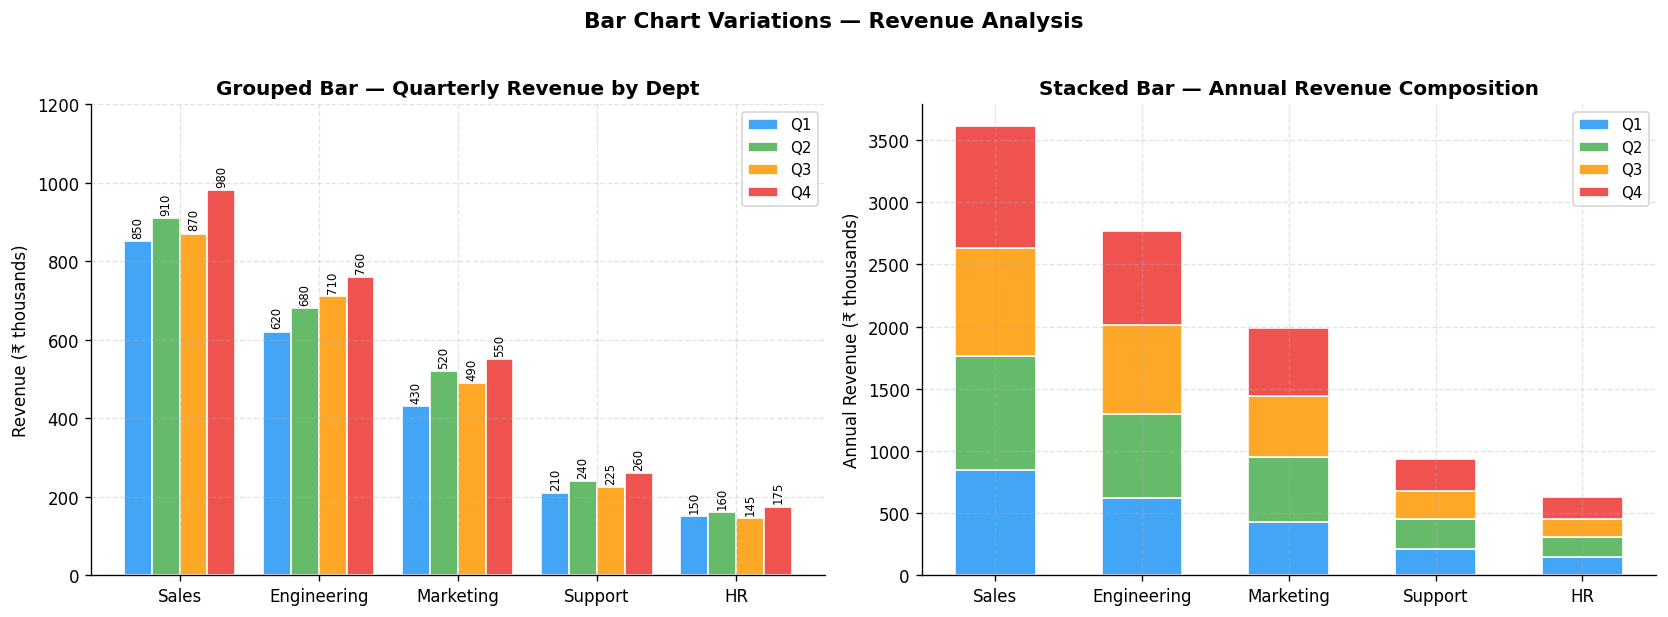

In [7]:
# ── Dataset: Department-wise revenue Q1–Q4 ────────────────────
departments = ['Sales', 'Engineering', 'Marketing', 'Support', 'HR']
q1 = [850, 620, 430, 210, 150]
q2 = [910, 680, 520, 240, 160]
q3 = [870, 710, 490, 225, 145]
q4 = [980, 760, 550, 260, 175]

x = np.arange(len(departments))   # [0, 1, 2, 3, 4]
width = 0.2                         # width of each individual bar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ═══════════════════════════════════════════════════════
# LEFT: GROUPED BAR CHART
# ═══════════════════════════════════════════════════════
# To place bars side by side, shift each group's x position by `width`
# Q1 starts at x - 1.5*width, Q2 at x - 0.5*width, etc.
bars1 = ax1.bar(x - 1.5*width, q1, width, label='Q1', color='#42A5F5', edgecolor='white')
bars2 = ax1.bar(x - 0.5*width, q2, width, label='Q2', color='#66BB6A', edgecolor='white')
bars3 = ax1.bar(x + 0.5*width, q3, width, label='Q3', color='#FFA726', edgecolor='white')
bars4 = ax1.bar(x + 1.5*width, q4, width, label='Q4', color='#EF5350', edgecolor='white')

# ── Add value labels ON TOP of each bar ───────────────────
# ax.bar_label() auto-places the text above each bar — added in Matplotlib 3.4
for bars in [bars1, bars2, bars3, bars4]:
    ax1.bar_label(bars, fontsize=7, padding=2, rotation=90, fmt='%d')

ax1.set_xticks(x)
ax1.set_xticklabels(departments, fontsize=10)
ax1.set_ylabel('Revenue (₹ thousands)', fontsize=10)
ax1.set_title('Grouped Bar — Quarterly Revenue by Dept', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1200)

# ═══════════════════════════════════════════════════════
# RIGHT: STACKED BAR CHART
# ═══════════════════════════════════════════════════════
# For stacked bars, pass `bottom=` to each subsequent layer.
# The bottom of each new bar = sum of all bars below it.
q1_arr = np.array(q1)
q2_arr = np.array(q2)
q3_arr = np.array(q3)
q4_arr = np.array(q4)

ax2.bar(x, q1_arr, width=0.55, label='Q1', color='#42A5F5', edgecolor='white')
ax2.bar(x, q2_arr, width=0.55, label='Q2', color='#66BB6A', edgecolor='white',
        bottom=q1_arr)
ax2.bar(x, q3_arr, width=0.55, label='Q3', color='#FFA726', edgecolor='white',
        bottom=q1_arr + q2_arr)
ax2.bar(x, q4_arr, width=0.55, label='Q4', color='#EF5350', edgecolor='white',
        bottom=q1_arr + q2_arr + q3_arr)

ax2.set_xticks(x)
ax2.set_xticklabels(departments, fontsize=10)
ax2.set_ylabel('Annual Revenue (₹ thousands)', fontsize=10)
ax2.set_title('Stacked Bar — Annual Revenue Composition', fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')

fig.suptitle('Bar Chart Variations — Revenue Analysis', fontsize=13,
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


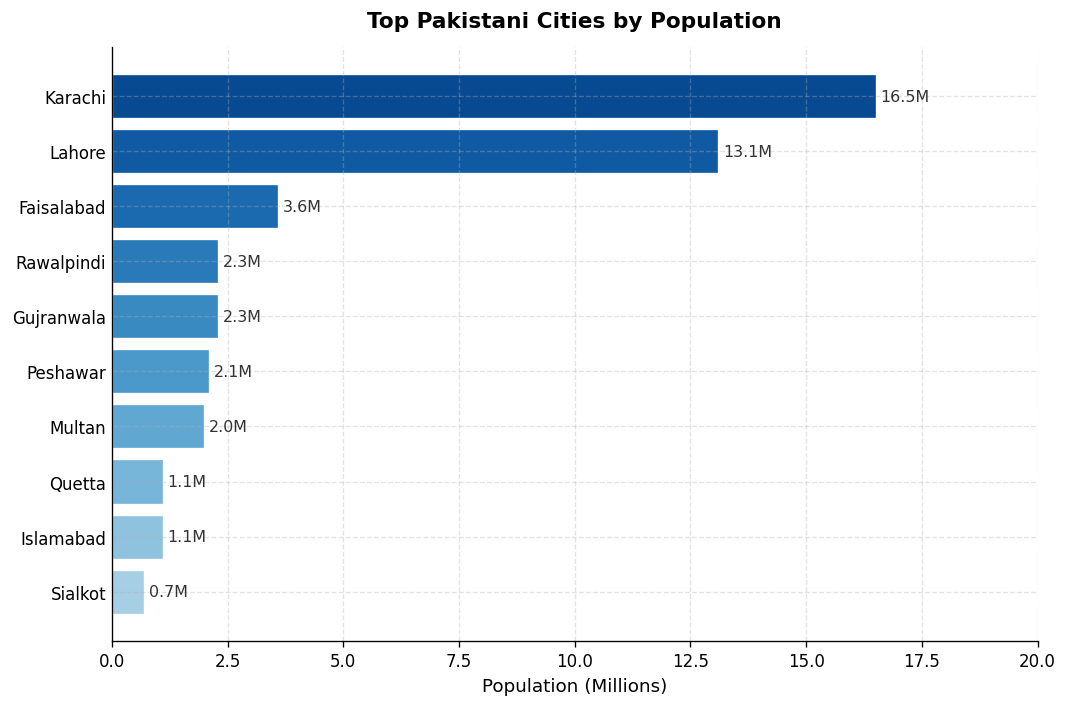

In [8]:
# ── Horizontal Bar Chart with sorted values ───────────────────
# Horizontal bars are ideal for long category names.
# Sorting the bars makes ranking immediately obvious.

cities   = ['Karachi','Lahore','Islamabad','Faisalabad','Rawalpindi',
            'Multan', 'Peshawar','Quetta','Sialkot','Gujranwala']
pop_M    = [16.5, 13.1, 1.1, 3.6, 2.3, 2.0, 2.1, 1.1, 0.7, 2.3]  # millions

# Sort both lists together by population (ascending so largest is at top)
sorted_pairs = sorted(zip(pop_M, cities))   # zip, sort, unzip
pop_sorted, cities_sorted = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 6))

# ── Color bars by rank using a colormap ───────────────────
# np.linspace gives evenly spaced values; cm.Blues maps them to colors
colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(cities)))

bars = ax.barh(cities_sorted, pop_sorted, color=colors,
               edgecolor='white', linewidth=0.8)

# ── Add data labels at the end of each bar ────────────────
for bar, val in zip(bars, pop_sorted):
    ax.text(val + 0.1,               # x position: slightly right of bar end
            bar.get_y() + bar.get_height()/2,  # y: vertically centered on bar
            f'{val:.1f}M',
            va='center', fontsize=9.5, color='#333')

ax.set_xlabel('Population (Millions)', fontsize=11)
ax.set_title('Top Pakistani Cities by Population',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 20)

# Remove y-axis tick marks (the labels are enough)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()


<a id='histogram'></a>
## 6. Histograms — Distributions

A histogram shows the **distribution of a single numerical variable** — how the values are spread. It answers: "Are values clustered in the middle? Skewed? Bimodal?"

### Key parameter: `bins`
- Too **few bins** → smooth but hides structure
- Too **many bins** → noisy and hard to read
- Rule of thumb: start with `bins='auto'` and adjust

### Histogram vs Bar Chart
- **Bar chart**: categorical x-axis (Department, Month, Product)
- **Histogram**: numerical x-axis (continuous data split into ranges)


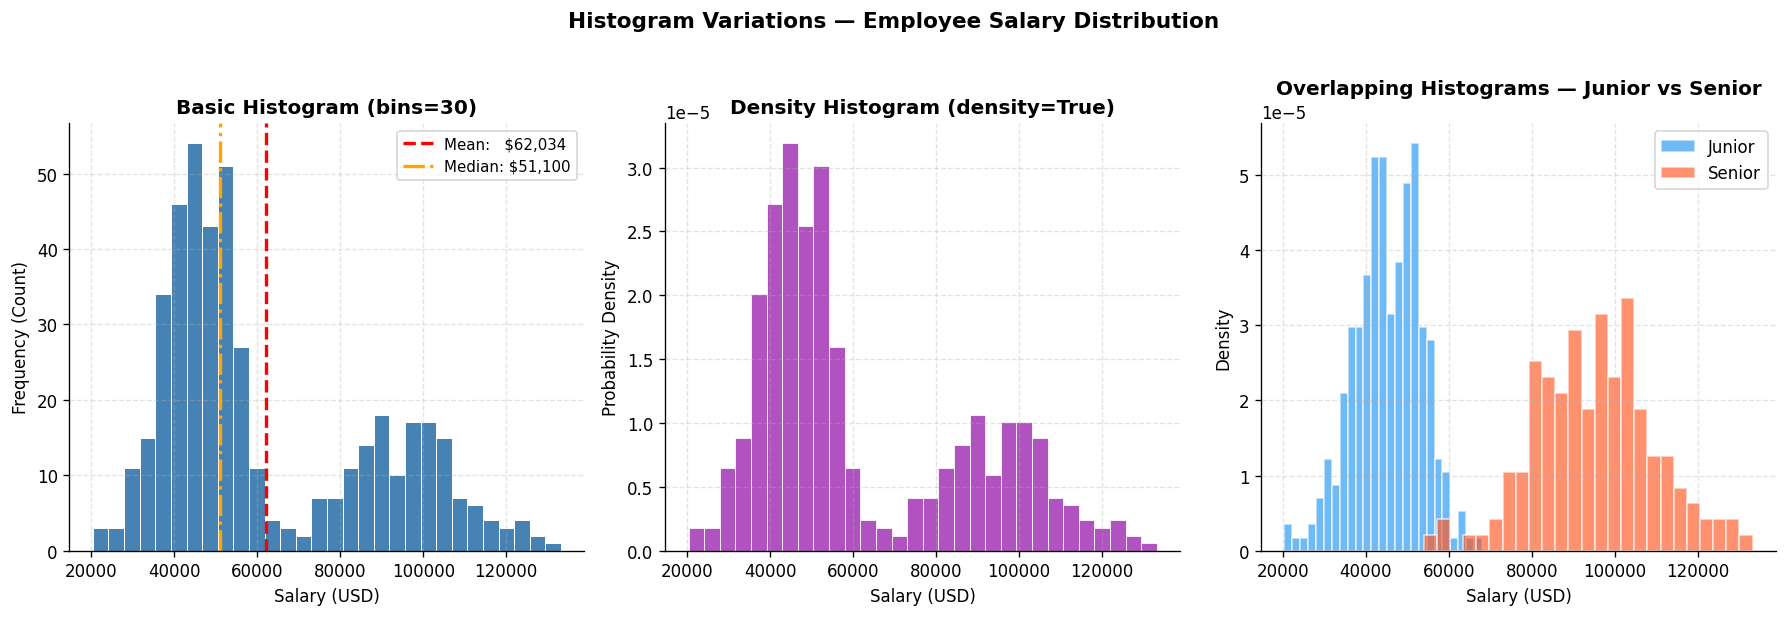

In [9]:
# ── Dataset: Employee salaries ─────────────────────────────────
np.random.seed(99)

# Simulate a realistic bimodal salary distribution:
# entry-level employees + senior employees form two humps
junior_salaries = np.random.normal(loc=45000,  scale=8000,  size=300)
senior_salaries = np.random.normal(loc=95000,  scale=15000, size=150)
all_salaries    = np.concatenate([junior_salaries, senior_salaries])
all_salaries    = np.clip(all_salaries, 20000, 180000)   # realistic range

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ═══════════════════════════════════════════════════════
# Plot 1: Basic Histogram
# ═══════════════════════════════════════════════════════
axes[0].hist(all_salaries,
             bins=30,             # number of bars (bins)
             color='steelblue',
             edgecolor='white',   # white gaps between bars for readability
             linewidth=0.6)
axes[0].set_title('Basic Histogram (bins=30)', fontweight='bold')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Frequency (Count)')

# ── Vertical lines for mean and median ────────────────────
mean_sal   = np.mean(all_salaries)
median_sal = np.median(all_salaries)
axes[0].axvline(mean_sal,   color='red',    lw=2, linestyle='--',
                label=f'Mean:   ${mean_sal:,.0f}')
axes[0].axvline(median_sal, color='orange', lw=2, linestyle='-.',
                label=f'Median: ${median_sal:,.0f}')
axes[0].legend(fontsize=9)

# ═══════════════════════════════════════════════════════
# Plot 2: Density (normalised) Histogram
# ═══════════════════════════════════════════════════════
# density=True normalises the histogram so the AREA = 1.
# Y-axis becomes probability density instead of count.
# Use this when comparing distributions of different sizes.
axes[1].hist(all_salaries, bins=30, density=True,
             color='#9C27B0', edgecolor='white', linewidth=0.6, alpha=0.8)
axes[1].set_title('Density Histogram (density=True)', fontweight='bold')
axes[1].set_xlabel('Salary (USD)')
axes[1].set_ylabel('Probability Density')

# ═══════════════════════════════════════════════════════
# Plot 3: Overlapping Histograms — compare two groups
# ═══════════════════════════════════════════════════════
axes[2].hist(junior_salaries, bins=25, alpha=0.65, color='#2196F3',
             edgecolor='white', label='Junior', density=True)
axes[2].hist(senior_salaries, bins=25, alpha=0.65, color='#FF5722',
             edgecolor='white', label='Senior', density=True)
# alpha < 1 makes bars semi-transparent so overlapping regions are visible
axes[2].set_title('Overlapping Histograms — Junior vs Senior', fontweight='bold')
axes[2].set_xlabel('Salary (USD)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=10)

fig.suptitle('Histogram Variations — Employee Salary Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id='pie'></a>
## 7. Pie & Donut Charts

Pie charts show **part-to-whole relationships** — how a total is divided among categories. They work best with **5 or fewer slices** and when the differences between slices are large enough to be visually obvious.

> **Honest note:** Many data professionals prefer bar charts over pie charts because humans judge angles less accurately than lengths. Use pie charts sparingly — mostly for reports and presentations where proportions (not exact values) are the message.


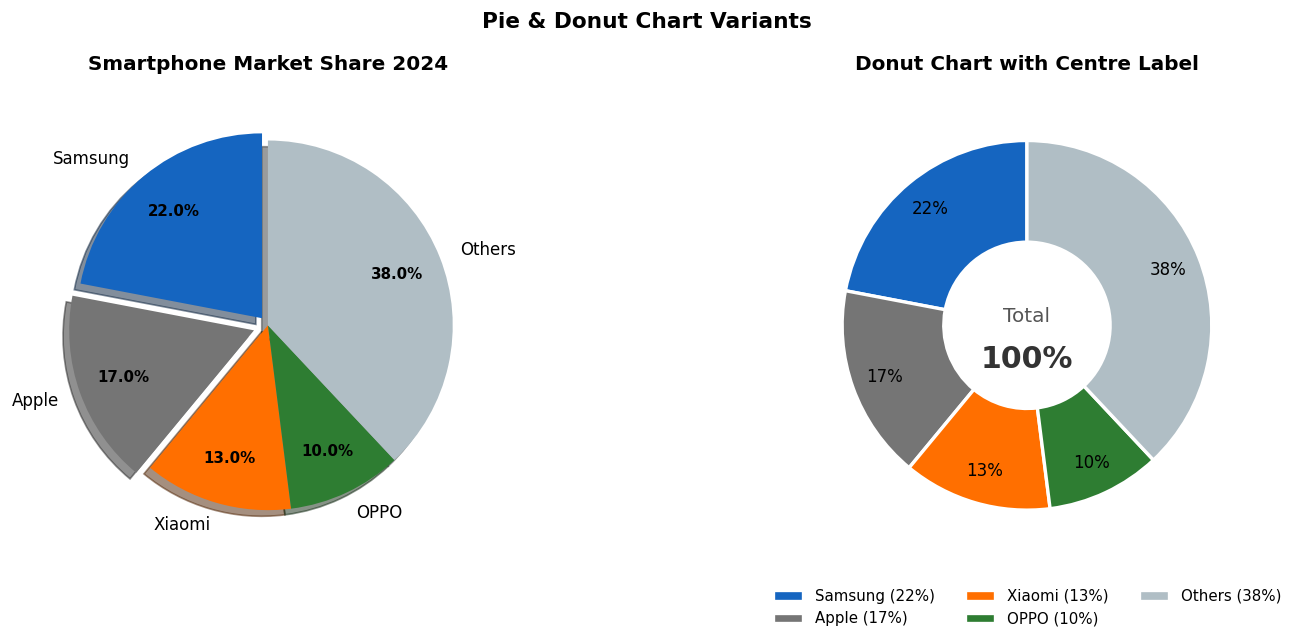

In [10]:
# ── Dataset: Market share of smartphone brands ────────────────
brands = ['Samsung', 'Apple', 'Xiaomi', 'OPPO', 'Others']
shares = [22, 17, 13, 10, 38]   # percentages, must sum to 100
colors = ['#1565C0', '#757575', '#FF6F00', '#2E7D32', '#B0BEC5']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ═══════════════════════════════════════════════════════
# LEFT: Standard Pie Chart
# ═══════════════════════════════════════════════════════
# explode= "pulls out" a slice for emphasis — value is the gap distance
explode = [0.05, 0.08, 0, 0, 0]   # slightly explode Samsung & Apple

wedges, texts, autotexts = ax1.pie(
    shares,
    labels=brands,
    autopct='%1.1f%%',      # autopct adds percentage labels inside each slice
                            # '%1.1f%%' → 1 decimal place + % sign
    colors=colors,
    explode=explode,
    startangle=90,          # rotate so the first slice starts at the top
    pctdistance=0.75,       # how far from center the pct text sits (1.0 = edge)
    labeldistance=1.12,     # how far the label sits from the edge
    shadow=True             # drop shadow for a polished look
)

# Adjust font sizes on generated text objects
for text in texts:      text.set_fontsize(10)
for at in autotexts:    at.set_fontsize(9); at.set_fontweight('bold')

ax1.set_title('Smartphone Market Share 2024', fontweight='bold', fontsize=12, pad=15)

# ═══════════════════════════════════════════════════════
# RIGHT: Donut Chart (pie with a white circle in the centre)
# ═══════════════════════════════════════════════════════
# A donut chart is a standard pie with a white circle drawn on top.
# The centre space can hold a key number or label.
wedges2, _, _ = ax2.pie(
    shares,
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    autopct='%1.0f%%',
    wedgeprops=dict(width=0.55,      # width < 1 creates the donut hole
                    edgecolor='white',
                    linewidth=2)
)

# ── Centre text ────────────────────────────────────────
# ax.text with coordinates (0,0) places text at the centre of the pie axes
ax2.text(0, 0.05, 'Total', ha='center', va='center',
         fontsize=12, color='#555')
ax2.text(0, -0.18, '100%', ha='center', va='center',
         fontsize=18, fontweight='bold', color='#333')

# ── External legend instead of slice labels ───────────────
ax2.legend(wedges2, [f'{b} ({s}%)' for b, s in zip(brands, shares)],
           loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, fontsize=9, frameon=False)

ax2.set_title('Donut Chart with Centre Label', fontweight='bold', fontsize=12, pad=15)

fig.suptitle('Pie & Donut Chart Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# PART 2 — Intermediate
---

<a id='subplots'></a>
## 8. Subplots — Multiple Panels in One Figure

Subplots let you combine multiple charts in a single figure. This is essential for dashboards, comparison panels, and academic papers.

### Three ways to create subplots

| Method | When to use |
|--------|------------|
| `plt.subplots(nrows, ncols)` | Regular grid — most common |
| `plt.subplots_adjust()` | Fine-tune spacing manually |
| `fig.add_gridspec()` | Unequal grid — some panels span multiple columns/rows |


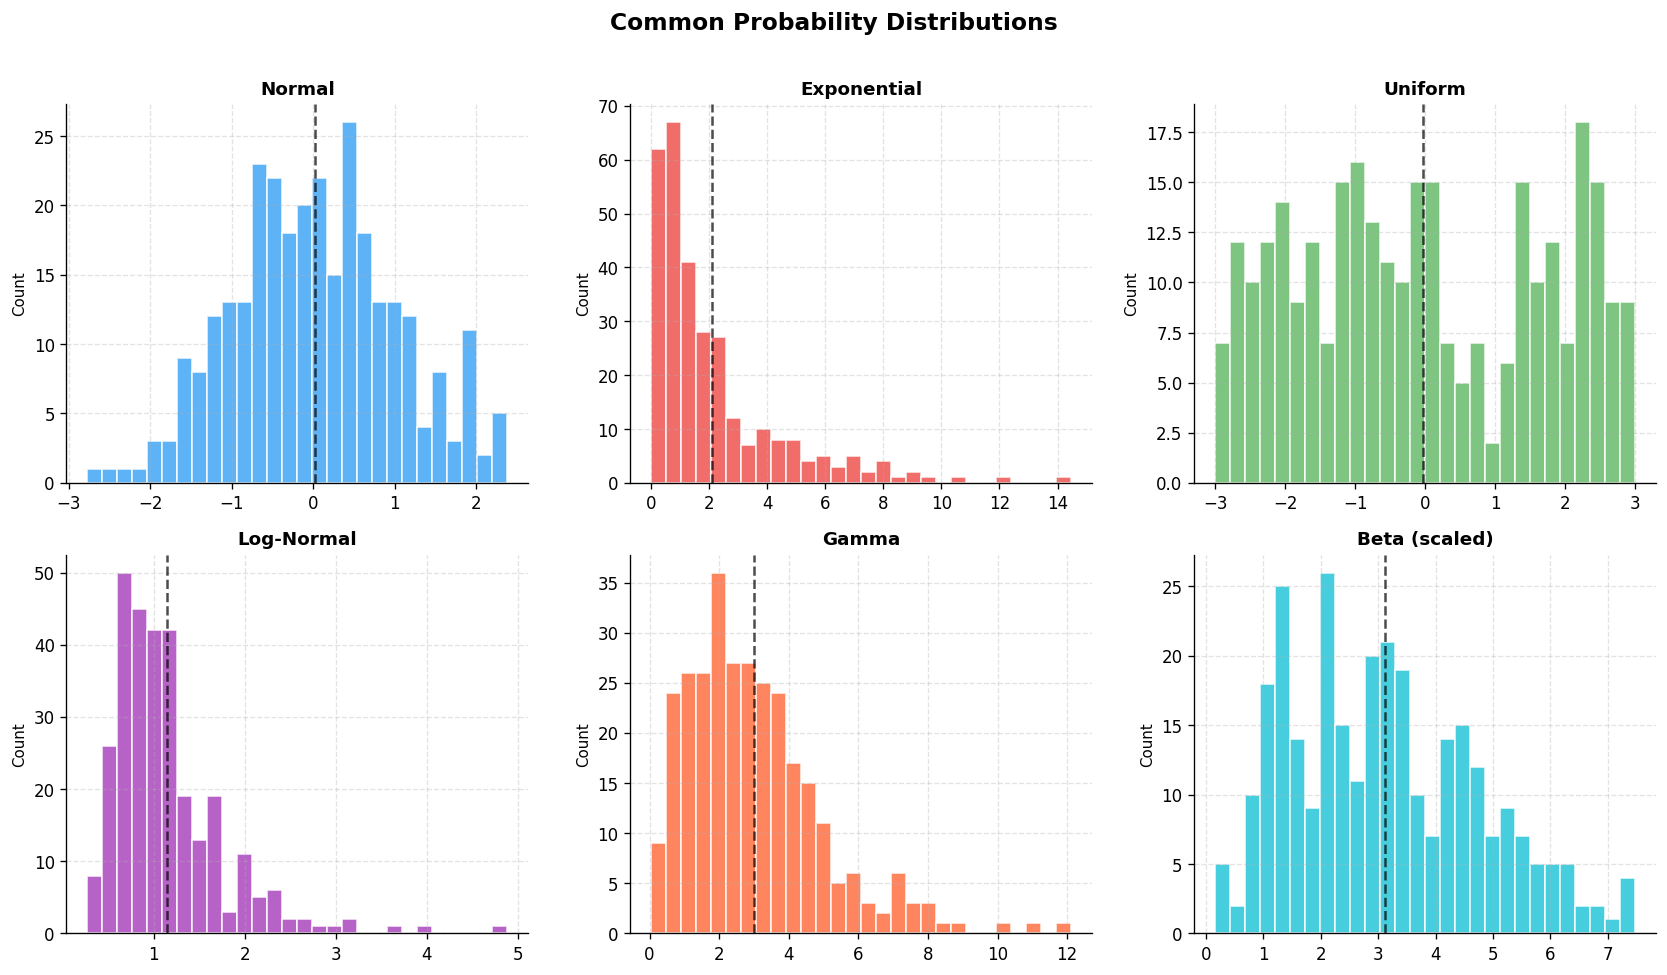

In [11]:
# ── plt.subplots() — the standard grid layout ─────────────────
# subplots(2, 3) creates a 2-row × 3-column grid of Axes.
# It returns the Figure and a 2D NumPy array of Axes objects.

np.random.seed(0)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
# axes.shape = (2, 3) — access individual Axes with axes[row, col]

data_sets = [
    np.random.normal(0, 1, 300),
    np.random.exponential(2, 300),
    np.random.uniform(-3, 3, 300),
    np.random.lognormal(0, 0.5, 300),
    np.random.gamma(2, 1.5, 300),
    np.random.beta(2, 5, 300) * 10,
]
titles = ['Normal', 'Exponential', 'Uniform',
          'Log-Normal', 'Gamma', 'Beta (scaled)']
colors = ['#42A5F5','#EF5350','#66BB6A','#AB47BC','#FF7043','#26C6DA']

# ── Flatten the 2D array so we can iterate with a simple loop ──
# axes.flat (or axes.ravel()) turns [[ax00, ax01, ax02], [ax10...]]
# into [ax00, ax01, ax02, ax10, ax11, ax12] — much easier to loop
for ax, data, title, color in zip(axes.flat, data_sets, titles, colors):
    ax.hist(data, bins=28, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count', fontsize=9)
    # Add a vertical line at the mean
    ax.axvline(np.mean(data), color='black', lw=1.5, linestyle='--', alpha=0.7)

fig.suptitle('Common Probability Distributions', fontsize=14, fontweight='bold', y=1.01)

# tight_layout + rect avoids suptitle overlapping the subplots
plt.tight_layout()
plt.show()


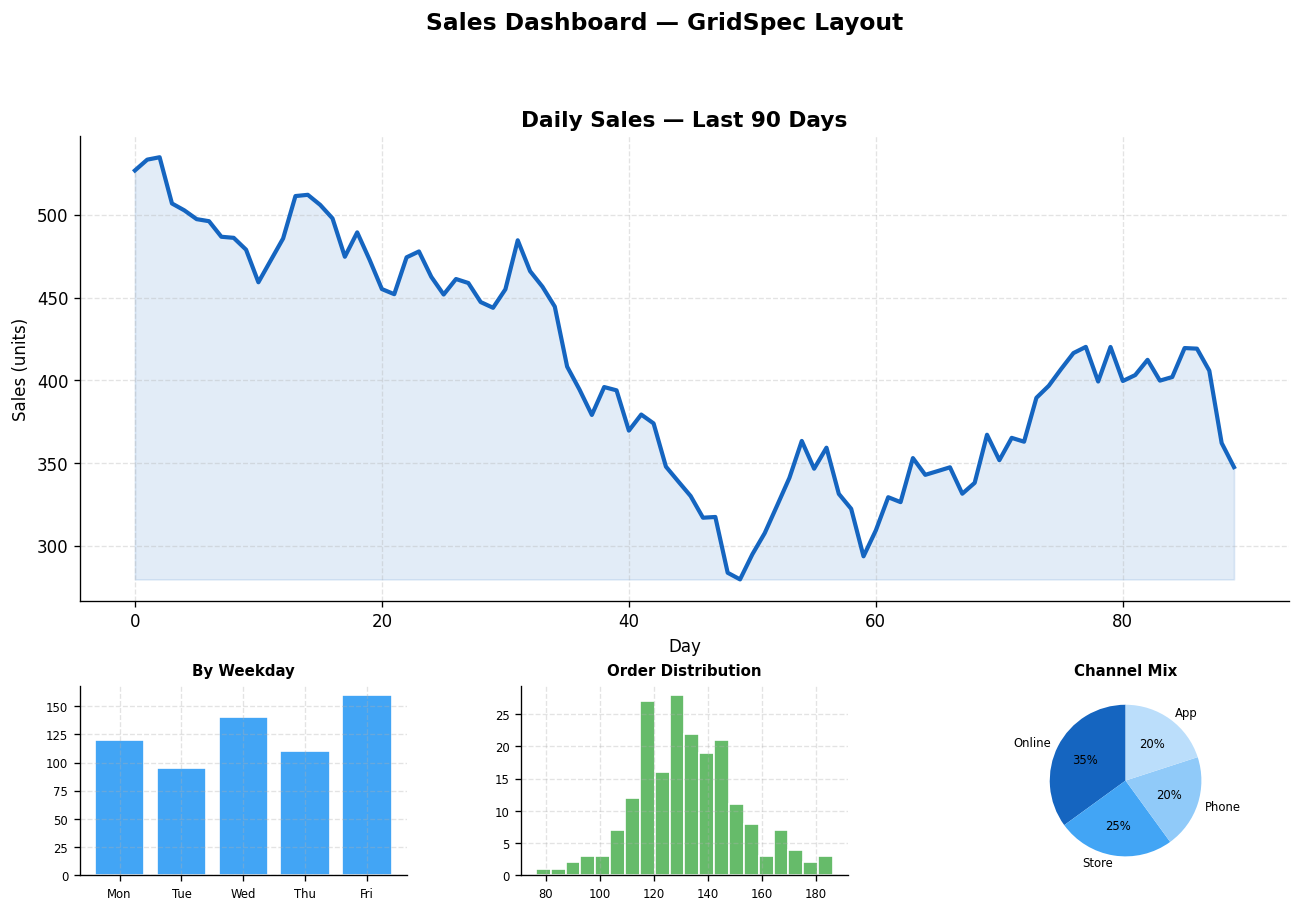

In [12]:
# ── GridSpec — unequal subplot layouts ────────────────────────
# GridSpec lets panels span multiple rows/columns — perfect for dashboards
# where one main chart should dominate and smaller charts support it.

fig = plt.figure(figsize=(13, 8))

# Create a 3×3 grid specification
gs = fig.add_gridspec(3, 3,
                      hspace=0.45,   # vertical space between rows
                      wspace=0.35)   # horizontal space between columns

# Main large plot: occupies top 2 rows, all 3 columns
ax_main = fig.add_subplot(gs[0:2, :])   # rows 0–1, all columns

# Bottom row: 3 equal small charts
ax_b1 = fig.add_subplot(gs[2, 0])
ax_b2 = fig.add_subplot(gs[2, 1])
ax_b3 = fig.add_subplot(gs[2, 2])

# ── Main: Line chart ───────────────────────────────────────
np.random.seed(3)
days = np.arange(90)
sales_main = 500 + np.cumsum(np.random.randn(90) * 15)  # random walk
ax_main.plot(days, sales_main, color='#1565C0', lw=2.5)
ax_main.fill_between(days, sales_main.min(), sales_main,
                     alpha=0.12, color='#1565C0')
ax_main.set_title('Daily Sales — Last 90 Days', fontsize=13, fontweight='bold')
ax_main.set_xlabel('Day')
ax_main.set_ylabel('Sales (units)')

# ── Bottom left: Bar chart ─────────────────────────────────
cats = ['Mon','Tue','Wed','Thu','Fri']
vals = [120, 95, 140, 110, 160]
ax_b1.bar(cats, vals, color='#42A5F5', edgecolor='white')
ax_b1.set_title('By Weekday', fontsize=9, fontweight='bold')
ax_b1.tick_params(axis='both', labelsize=7)

# ── Bottom middle: Histogram ────────────────────────────────
ax_b2.hist(np.random.normal(130, 20, 200), bins=20,
           color='#66BB6A', edgecolor='white')
ax_b2.set_title('Order Distribution', fontsize=9, fontweight='bold')
ax_b2.tick_params(axis='both', labelsize=7)

# ── Bottom right: Pie ──────────────────────────────────────
ax_b3.pie([35, 25, 20, 20], labels=['Online','Store','Phone','App'],
          colors=['#1565C0','#42A5F5','#90CAF9','#BBDEFB'],
          autopct='%d%%', startangle=90,
          textprops={'fontsize': 7})
ax_b3.set_title('Channel Mix', fontsize=9, fontweight='bold')

fig.suptitle('Sales Dashboard — GridSpec Layout', fontsize=14,
             fontweight='bold', y=1.01)
plt.show()


<a id='styles'></a>
## 9. Colors, Styles & Themes

Visual appearance dramatically affects how a chart is perceived. Matplotlib gives you multiple levels of styling control:

1. **Style sheets** — one-line global theme change
2. **Colormaps** — scientific, sequential, diverging, and qualitative palettes
3. **Per-element styling** — control individual lines, markers, fills


In [13]:
# ── Built-in style sheets ────────────────────────────────────
# plt.style.use() applies a global visual theme — like a CSS stylesheet.
# Popular options: 'seaborn-v0_8', 'ggplot', 'fivethirtyeight',
#                 'dark_background', 'bmh', 'classic'

available = plt.style.available
print("All available styles:")
print([s for s in available if 'seaborn' not in s or 'v0_8' in s][:20])


All available styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted']


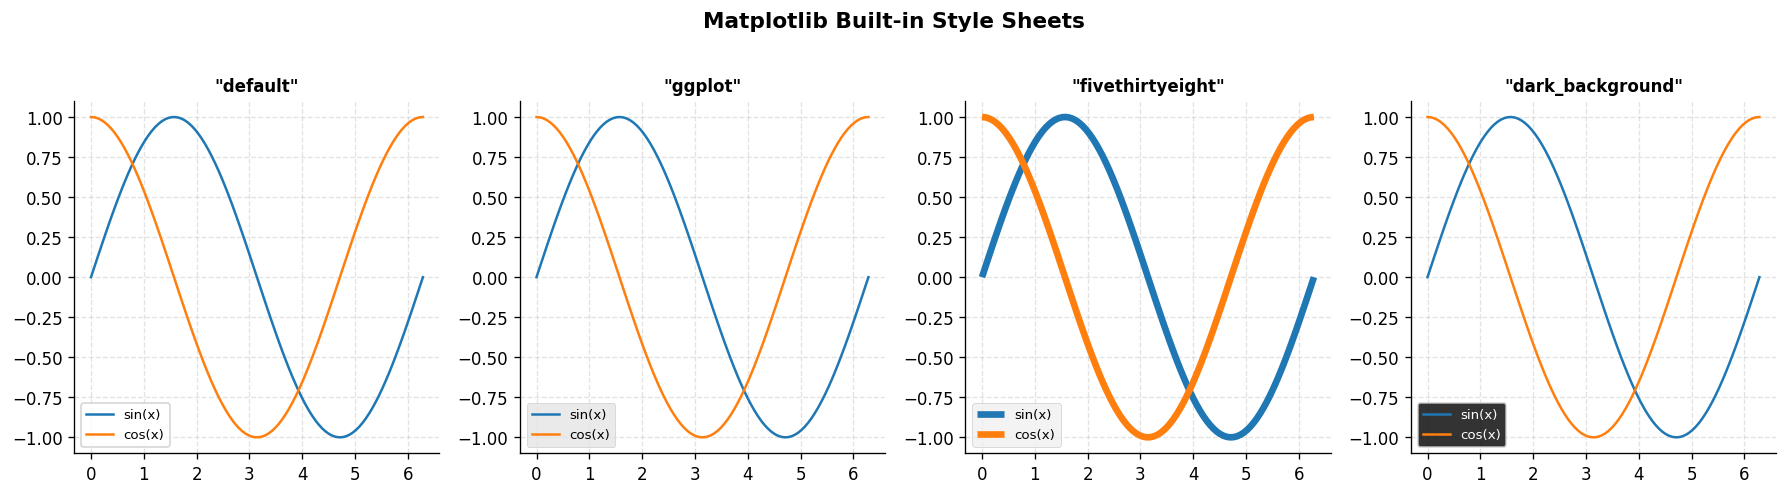

In [14]:
# ── Side-by-side style comparison ───────────────────────────
x = np.linspace(0, 2 * np.pi, 100)

styles_to_compare = ['default', 'ggplot', 'fivethirtyeight', 'dark_background']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, style in zip(axes, styles_to_compare):
    with plt.style.context(style):   # context manager — applies style ONLY inside the block
        ax.plot(x, np.sin(x), label='sin(x)')
        ax.plot(x, np.cos(x), label='cos(x)')
        ax.set_title(f'"{style}"', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

fig.suptitle('Matplotlib Built-in Style Sheets', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


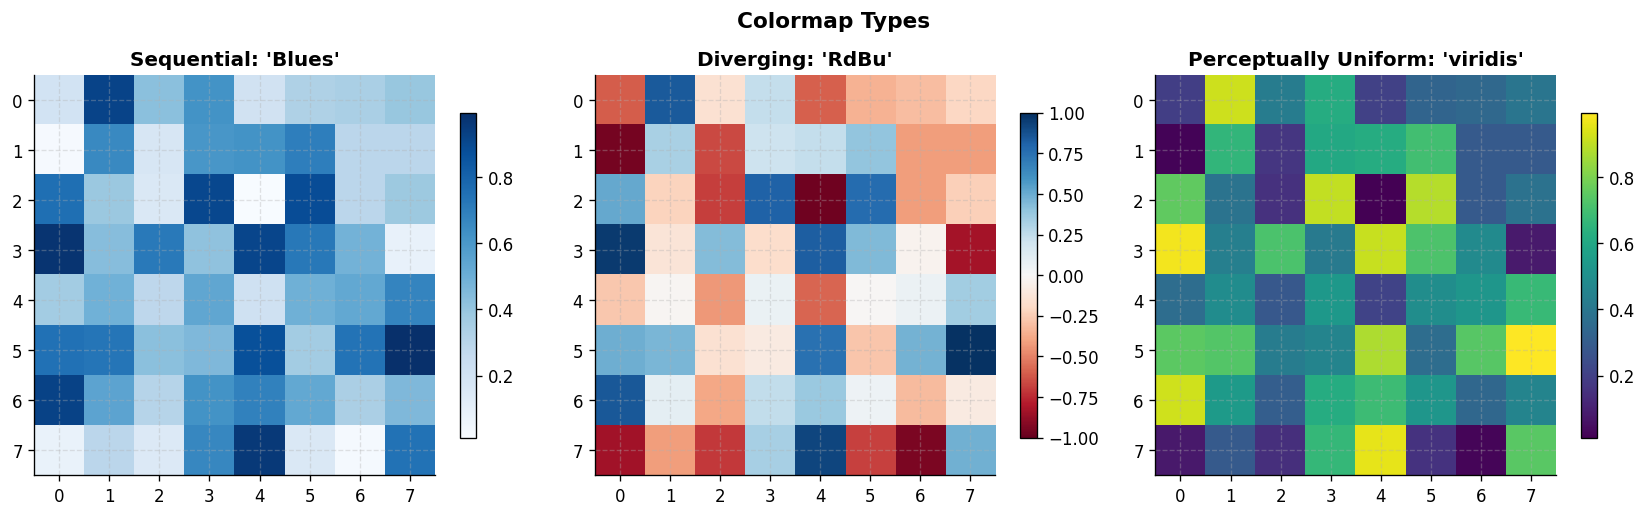

In [15]:
# ── Colors in Matplotlib: 4 ways to specify them ─────────────
#
# 1. Named color:   'red', 'steelblue', 'salmon', 'limegreen'
# 2. Hex code:      '#FF5733',  '#2ECC71'
# 3. RGB tuple:     (0.2, 0.6, 0.9)   — values 0.0–1.0
# 4. From colormap: plt.cm.viridis(0.5) → RGBA at position 0.5

# ── Colormaps — sequential, diverging, qualitative ─────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

data = np.random.rand(8, 8)

# Sequential: goes from light to dark — good for magnitude
im1 = axes[0].imshow(data, cmap='Blues')
axes[0].set_title("Sequential: 'Blues'", fontweight='bold')
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# Diverging: has a neutral midpoint — good for +/- data (correlations, change)
data_div = (data - 0.5) * 2   # scale to -1 … +1
im2 = axes[1].imshow(data_div, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title("Diverging: 'RdBu'", fontweight='bold')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

# Perceptually uniform: viridis, plasma, inferno — safe for colorblind readers
im3 = axes[2].imshow(data, cmap='viridis')
axes[2].set_title("Perceptually Uniform: 'viridis'", fontweight='bold')
fig.colorbar(im3, ax=axes[2], shrink=0.8)

fig.suptitle('Colormap Types', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


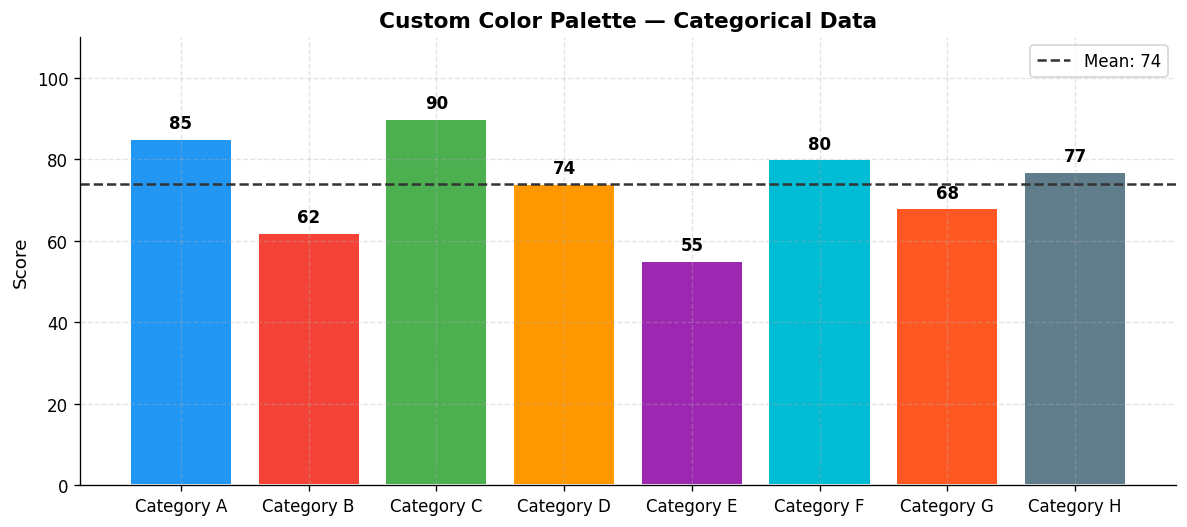

In [16]:
# ── Custom color palette for categorical data ─────────────────
# For qualitative (categorical) data, use visually distinct, accessible colors.
# Here is a hand-picked palette that works well in presentations.

PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800',
           '#9C27B0', '#00BCD4', '#FF5722', '#607D8B']

categories = ['Category A', 'Category B', 'Category C', 'Category D',
              'Category E', 'Category F', 'Category G', 'Category H']
values     = [85, 62, 90, 74, 55, 80, 68, 77]

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.bar(categories, values, color=PALETTE, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Custom Color Palette — Categorical Data', fontsize=13, fontweight='bold')

# ── Horizontal reference line ─────────────────────────────
ax.axhline(y=np.mean(values), color='#333', linestyle='--',
           lw=1.5, label=f'Mean: {np.mean(values):.0f}')
ax.legend()

plt.tight_layout()
plt.show()


<a id='annotations'></a>
## 10. Annotations, Text & Arrows

Annotations turn a plain chart into a **story**. They highlight key moments, explain anomalies, and guide the reader's eye to what matters most.

| Method | Use |
|--------|-----|
| `ax.annotate()` | Arrow + text pointing to a specific data point |
| `ax.text()` | Free-floating text anywhere on the axes |
| `ax.axhline()` / `ax.axvline()` | Reference lines (targets, thresholds, averages) |
| `ax.axhspan()` / `ax.axvspan()` | Shaded regions (e.g., recession periods, normal range) |


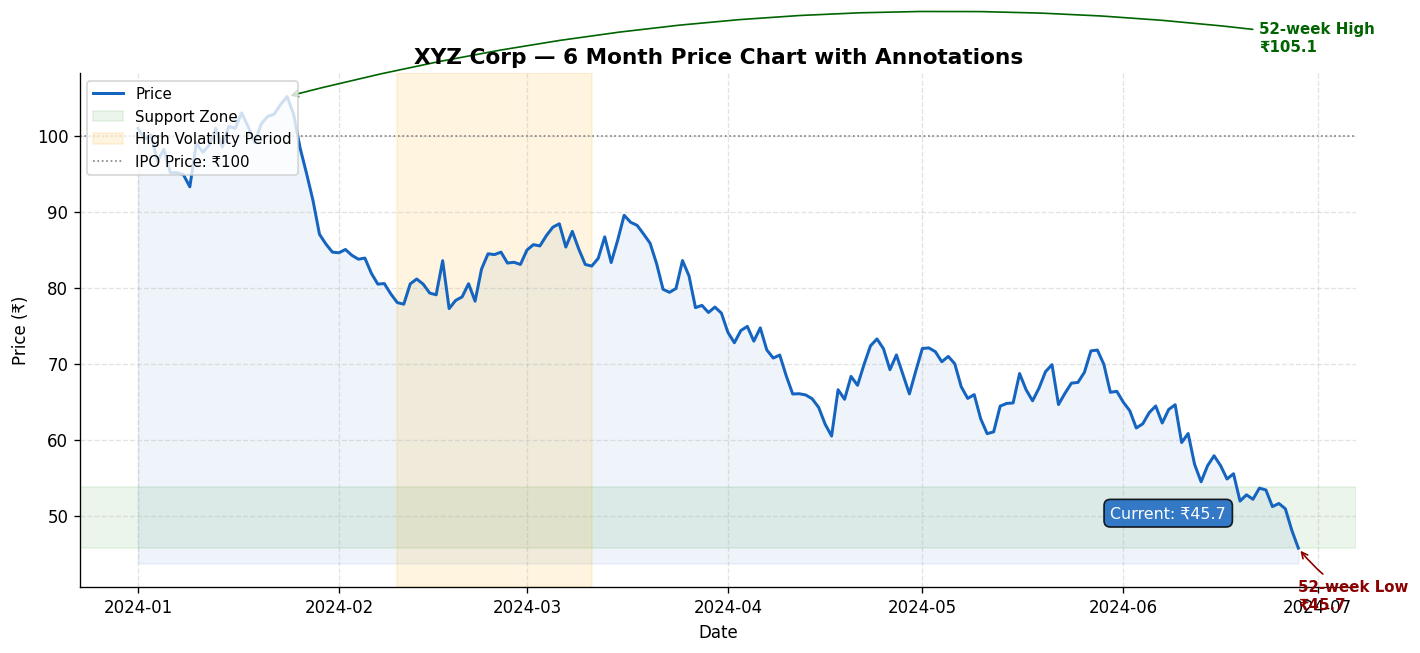

In [17]:
# ── Real-world example: Stock-like price chart with annotations ──
np.random.seed(12)
days = pd.date_range('2024-01-01', periods=180, freq='D')
price = 100 + np.cumsum(np.random.randn(180) * 2)

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(days, price, color='#1565C0', lw=1.8, label='Price')
ax.fill_between(days, price.min() - 2, price, alpha=0.07, color='#1565C0')

# ── axhspan: shade a horizontal band (e.g., "support zone") ──
# axhspan(ymin, ymax) fills the full width of the plot between two y values
ax.axhspan(price.min(), price.min() + 8,
           color='green', alpha=0.08, label='Support Zone')

# ── axvspan: shade a vertical band (a date range) ─────────
# axvspan(xmin, xmax) fills between two x values across the full height
ax.axvspan(days[40], days[70], color='orange', alpha=0.12, label='High Volatility Period')

# ── axhline: reference line at the starting price ─────────
ax.axhline(100, color='gray', lw=1, linestyle=':', label='IPO Price: ₹100')

# ── Annotate the peak ─────────────────────────────────────
peak_idx = np.argmax(price)
ax.annotate(f'52-week High\n₹{price[peak_idx]:.1f}',
            xy=(days[peak_idx], price[peak_idx]),
            xytext=(days[peak_idx - 30], price[peak_idx] + 6),
            fontsize=9, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen',
                            connectionstyle='arc3,rad=0.1'))   # curved arrow

# ── Annotate the trough ───────────────────────────────────
trough_idx = np.argmin(price)
ax.annotate(f'52-week Low\n₹{price[trough_idx]:.1f}',
            xy=(days[trough_idx], price[trough_idx]),
            xytext=(days[min(trough_idx + 20, len(days)-1)], price[trough_idx] - 8),
            fontsize=9, color='darkred', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred',
                            connectionstyle='arc3,rad=-0.1'))

# ── Text box with background ─────────────────────────────
# bbox= adds a box around the text (fancybox style)
current_price = price[-1]
ax.text(days[-30], price[-1] + 4,
        f'Current: ₹{current_price:.1f}',
        fontsize=9.5, color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1565C0', alpha=0.85))

ax.set_title('XYZ Corp — 6 Month Price Chart with Annotations',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (₹)')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()


<a id='twinx'></a>
## 11. Twin Axes — Dual Y-Axis

Sometimes two related variables have **completely different scales** (e.g., revenue in millions and conversion rate in %). Plotting them on separate y-axes on the same chart reveals correlations that two separate charts would miss.

- `ax.twinx()` — shares the **x-axis**, creates a second y-axis on the right
- `ax.twiny()` — shares the **y-axis**, creates a second x-axis on top


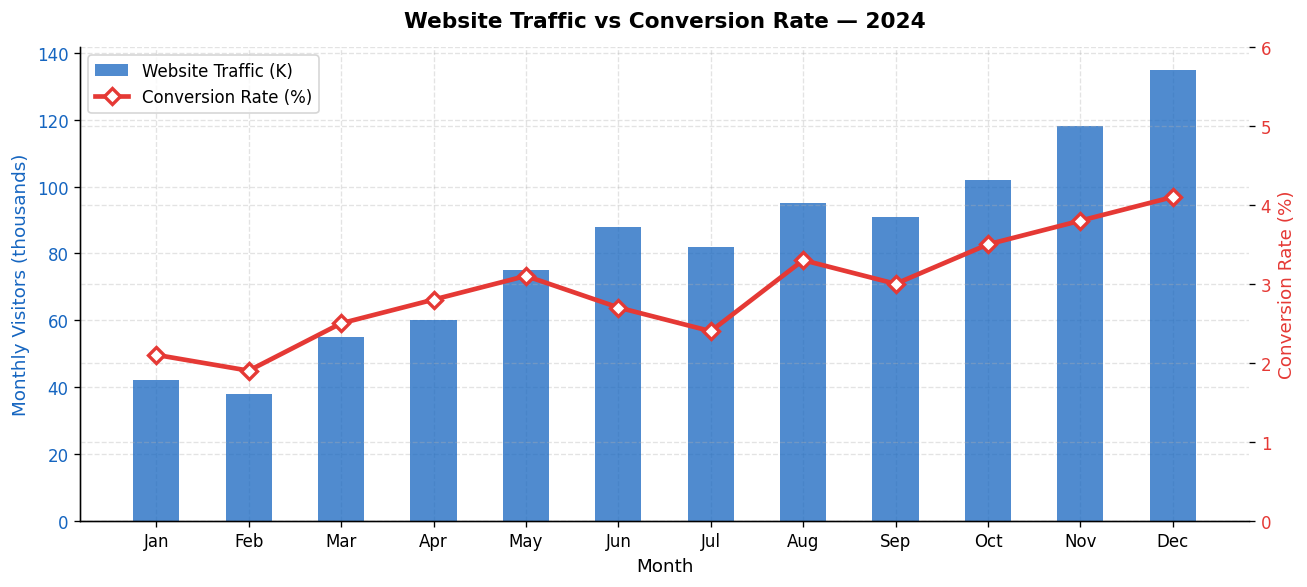

In [18]:
# ── Dataset: Monthly website traffic and conversion rate ────────
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

traffic_K   = [42, 38, 55, 60, 75, 88, 82, 95, 91, 102, 118, 135]  # thousands of visitors
conversion  = [2.1, 1.9, 2.5, 2.8, 3.1, 2.7, 2.4, 3.3, 3.0, 3.5, 3.8, 4.1]  # %

fig, ax1 = plt.subplots(figsize=(11, 5))

# ── Primary axis (left): Traffic ──────────────────────────
color_traffic = '#1565C0'
ax1.bar(x, traffic_K, width=0.5, color=color_traffic,
        alpha=0.75, label='Website Traffic (K)', zorder=2)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Monthly Visitors (thousands)', fontsize=11, color=color_traffic)
ax1.tick_params(axis='y', labelcolor=color_traffic)  # match tick color to data color
ax1.set_xticks(x)
ax1.set_xticklabels(months)

# ── Secondary axis (right): Conversion rate ───────────────
# ax1.twinx() creates a NEW Axes sharing the same x-axis.
# ax2 sits "on top" of ax1, with its own y-scale on the RIGHT side.
color_conv = '#E53935'
ax2 = ax1.twinx()
ax2.plot(x, conversion,
         color=color_conv, lw=2.8, marker='D',
         markersize=7, markerfacecolor='white',
         markeredgewidth=2, label='Conversion Rate (%)', zorder=3)
ax2.set_ylabel('Conversion Rate (%)', fontsize=11, color=color_conv)
ax2.tick_params(axis='y', labelcolor=color_conv)
ax2.set_ylim(0, 6)

# ── Combined legend (merge both axes' handles) ────────────
# Since two Axes exist, we must manually combine their legend entries
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=10)

ax1.set_title('Website Traffic vs Conversion Rate — 2024',
              fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


<a id='boxplot'></a>
## 12. Box Plots & Violin Plots — Statistical Summaries

Box plots (also called "box-and-whisker plots") pack a lot of statistical information into one compact visual:

```
         |---- whisker (1.5×IQR above Q3)
    ┌────┤
    │    │  ← Q3 (75th percentile)
    │  ──┤  ← Median (Q2, 50th percentile)
    │    │  ← Q1 (25th percentile)
    └────┤
         |---- whisker (1.5×IQR below Q1)
         ○  ← Outlier (beyond whiskers)
```

**IQR (Interquartile Range)** = Q3 − Q1. Points beyond 1.5×IQR are plotted as individual dots (outliers).


/tmp/ipykernel_574/1165204678.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(score_data,


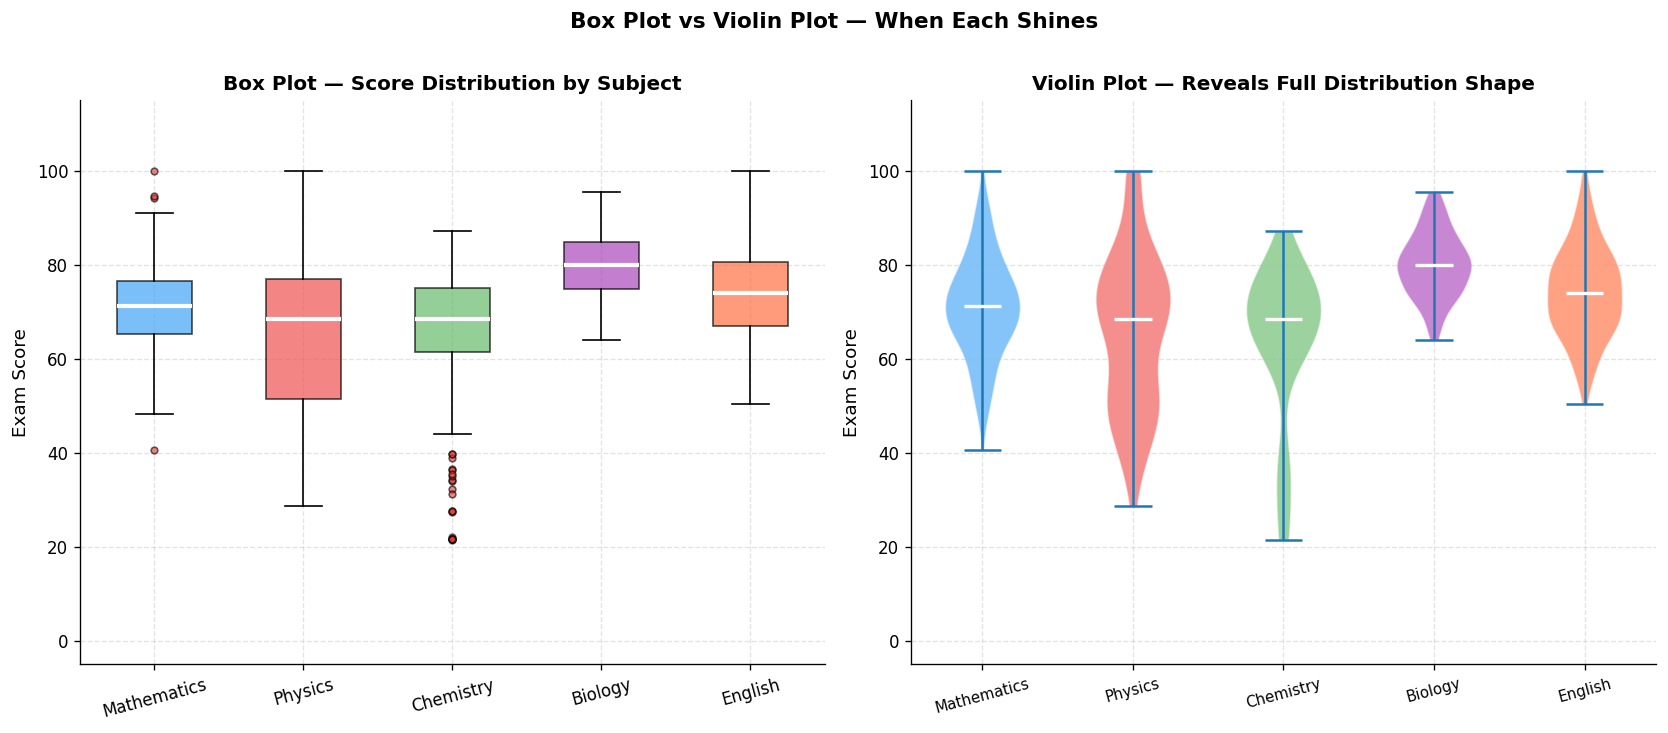

In [19]:
# ── Dataset: Exam scores across 5 subjects ────────────────────
np.random.seed(42)

subjects  = ['Mathematics', 'Physics', 'Chemistry', 'Biology', 'English']
# Each subject has a different distribution — different spread, mean, and skew
score_data = [
    np.random.normal(72, 12, 120),           # Math: moderate spread
    np.random.normal(65, 18, 120),           # Physics: wide spread (hard subject)
    np.append(np.random.normal(70, 8, 100),  # Chemistry: bimodal + some outliers
              np.random.uniform(20, 40, 20)),
    np.random.normal(80, 7, 120),            # Biology: narrow spread, high mean
    np.random.normal(75, 10, 120),           # English: moderate
]
# Clip all to realistic range
score_data = [np.clip(s, 0, 100) for s in score_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ═══════════════════════════════════════════════════════
# LEFT: Box Plot
# ═══════════════════════════════════════════════════════
bp = ax1.boxplot(score_data,
                 labels=subjects,
                 patch_artist=True,    # fill boxes with color (default is just outlines)
                 notch=False,          # notch=True adds a confidence notch around median
                 showfliers=True,      # show outlier dots beyond the whiskers
                 flierprops=dict(marker='o', markerfacecolor='#E53935',
                                 markersize=4, alpha=0.6))

# Colorize each box individually
box_colors = ['#42A5F5','#EF5350','#66BB6A','#AB47BC','#FF7043']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Median lines: make them stand out
for median_line in bp['medians']:
    median_line.set_color('white')
    median_line.set_linewidth(2.5)

ax1.set_title('Box Plot — Score Distribution by Subject',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Exam Score', fontsize=11)
ax1.tick_params(axis='x', labelrotation=15)
ax1.set_ylim(-5, 115)

# ═══════════════════════════════════════════════════════
# RIGHT: Violin Plot — shows full distribution shape
# ═══════════════════════════════════════════════════════
# A violin plot is a box plot + kernel density estimate (KDE).
# The width of the "violin" at each y-value shows how many data points are there.
# It reveals bimodal or unusual distributions that a box plot would hide.
vp = ax2.violinplot(score_data,
                    positions=range(1, len(subjects)+1),
                    showmedians=True,    # draw a line at the median
                    showextrema=True)    # draw lines at min and max

# Colorize violins
for i, (body, color) in enumerate(zip(vp['bodies'], box_colors)):
    body.set_facecolor(color)
    body.set_alpha(0.65)
    body.set_edgecolor('white')

vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax2.set_xticks(range(1, len(subjects)+1))
ax2.set_xticklabels(subjects, rotation=15, fontsize=9)
ax2.set_title('Violin Plot — Reveals Full Distribution Shape',
              fontweight='bold', fontsize=12)
ax2.set_ylabel('Exam Score', fontsize=11)
ax2.set_ylim(-5, 115)

# Note: Chemistry (3rd violin) clearly shows a bimodal shape — visible in
# violin but hidden in the box plot! This is the key advantage of violin plots.

fig.suptitle('Box Plot vs Violin Plot — When Each Shines',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
# PART 3 — Advanced & Practical Applications
---

<a id='heatmap'></a>
## 13. Heatmaps — Correlation & Confusion Matrices

Heatmaps encode a 2D matrix of numbers as colors. They're used for:
- **Correlation matrices** — which features are related in a dataset?
- **Confusion matrices** — how well did a classifier perform?
- **Calendar heatmaps** — activity over time (e.g., GitHub contributions)
- **Feature importance grids**

Matplotlib's `imshow()` is the core tool; we add text annotations manually.


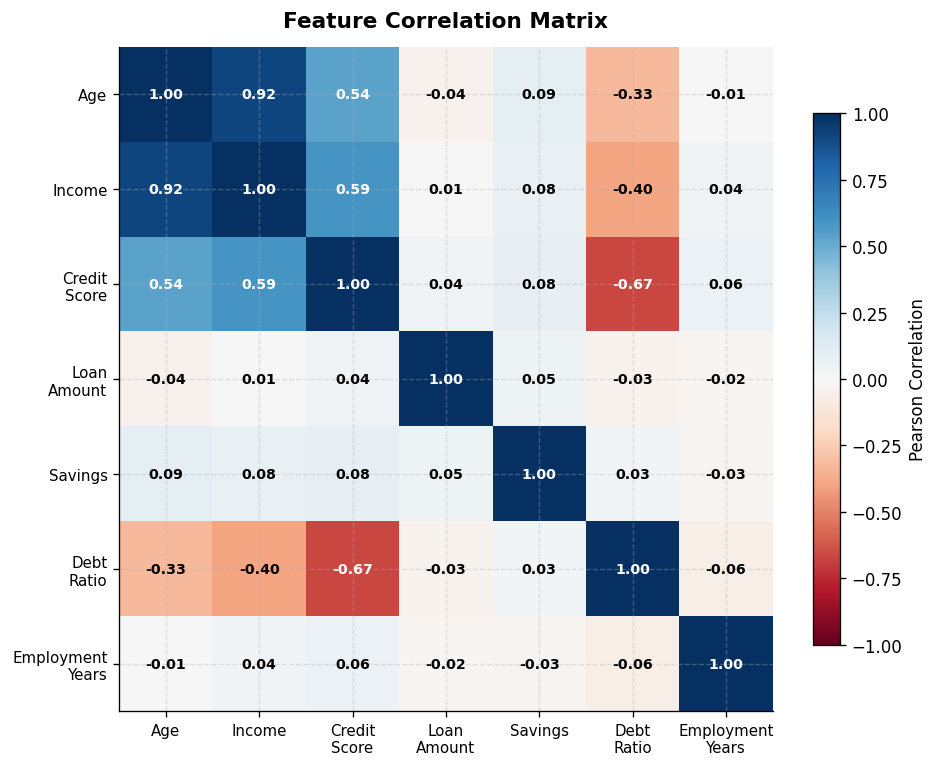

In [20]:
# ── 1. Correlation Matrix Heatmap ─────────────────────────────
np.random.seed(10)

# Simulate a realistic feature correlation matrix for an ML dataset
feature_names = ['Age', 'Income', 'Credit\nScore', 'Loan\nAmount',
                 'Savings', 'Debt\nRatio', 'Employment\nYears']
n_feat = len(feature_names)

# Build a symmetric correlation matrix (values in -1 to 1)
# np.corrcoef computes pairwise correlations from random data
raw = np.random.randn(200, n_feat)
# Inject some actual correlations to make the heatmap interesting
raw[:, 1] = raw[:, 0] * 0.7 + np.random.randn(200) * 0.3   # Income ~ Age
raw[:, 2] = raw[:, 1] * 0.5 + np.random.randn(200) * 0.5   # CreditScore ~ Income
raw[:, 5] = -raw[:, 2] * 0.6 + np.random.randn(200) * 0.4  # DebtRatio ~ -CreditScore

corr = np.corrcoef(raw, rowvar=False)   # rowvar=False → each column is a variable

fig, ax = plt.subplots(figsize=(8, 6.5))

# imshow() treats the matrix as an image: each cell = one pixel
im = ax.imshow(corr, cmap='RdBu',    # RdBu: red=positive, blue=negative
               vmin=-1, vmax=1,       # fix scale to full correlation range
               aspect='auto')

# ── Add a colorbar ─────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Pearson Correlation', fontsize=10)

# ── Annotate each cell with its value ─────────────────────
for i in range(n_feat):
    for j in range(n_feat):
        val = corr[i, j]
        # Choose text color based on cell darkness for legibility
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=8.5, color=text_color, fontweight='bold')

ax.set_xticks(range(n_feat))
ax.set_yticks(range(n_feat))
ax.set_xticklabels(feature_names, fontsize=9)
ax.set_yticklabels(feature_names, fontsize=9)

ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


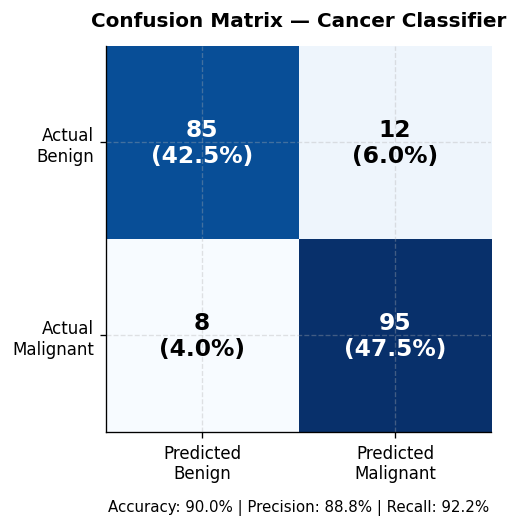

In [21]:
# ── 2. Confusion Matrix Heatmap ──────────────────────────────
# A confusion matrix shows classification performance:
# rows = actual class, columns = predicted class
# Diagonal = correct predictions (want these HIGH)
# Off-diagonal = errors (want these LOW)

class_names = ['Benign', 'Malignant']
# Simulated confusion matrix: [[TN, FP], [FN, TP]]
conf_matrix = np.array([[85, 12],
                         [ 8, 95]])

fig, ax = plt.subplots(figsize=(5.5, 4.5))

im = ax.imshow(conf_matrix, cmap='Blues')

# ── Annotate with counts AND percentages ──────────────────
total = conf_matrix.sum()
for i in range(2):
    for j in range(2):
        count = conf_matrix[i, j]
        pct   = count / total * 100
        # White text on dark cells; black text on light cells
        text_color = 'white' if conf_matrix[i, j] > conf_matrix.max() * 0.5 else 'black'
        ax.text(j, i, f'{count}\n({pct:.1f}%)',
                ha='center', va='center',
                fontsize=14, fontweight='bold', color=text_color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nBenign', 'Predicted\nMalignant'], fontsize=10)
ax.set_yticklabels(['Actual\nBenign', 'Actual\nMalignant'], fontsize=10)
ax.set_title('Confusion Matrix — Cancer Classifier', fontsize=12, fontweight='bold', pad=12)

# ── Key metrics ───────────────────────────────────────────
TP = conf_matrix[1,1]; FP = conf_matrix[0,1]
FN = conf_matrix[1,0]; TN = conf_matrix[0,0]
precision = TP/(TP+FP)
recall    = TP/(TP+FN)
accuracy  = (TP+TN)/total

ax.set_xlabel(f'Accuracy: {accuracy:.1%} | Precision: {precision:.1%} | Recall: {recall:.1%}',
              fontsize=9, labelpad=10)

plt.tight_layout()
plt.show()


<a id='area'></a>
## 14. Filled Area & Stacked Charts

Area charts are line charts with the space below the line filled in. They emphasise **volume and magnitude over time**. The stacked variant shows both the total and the individual parts simultaneously.


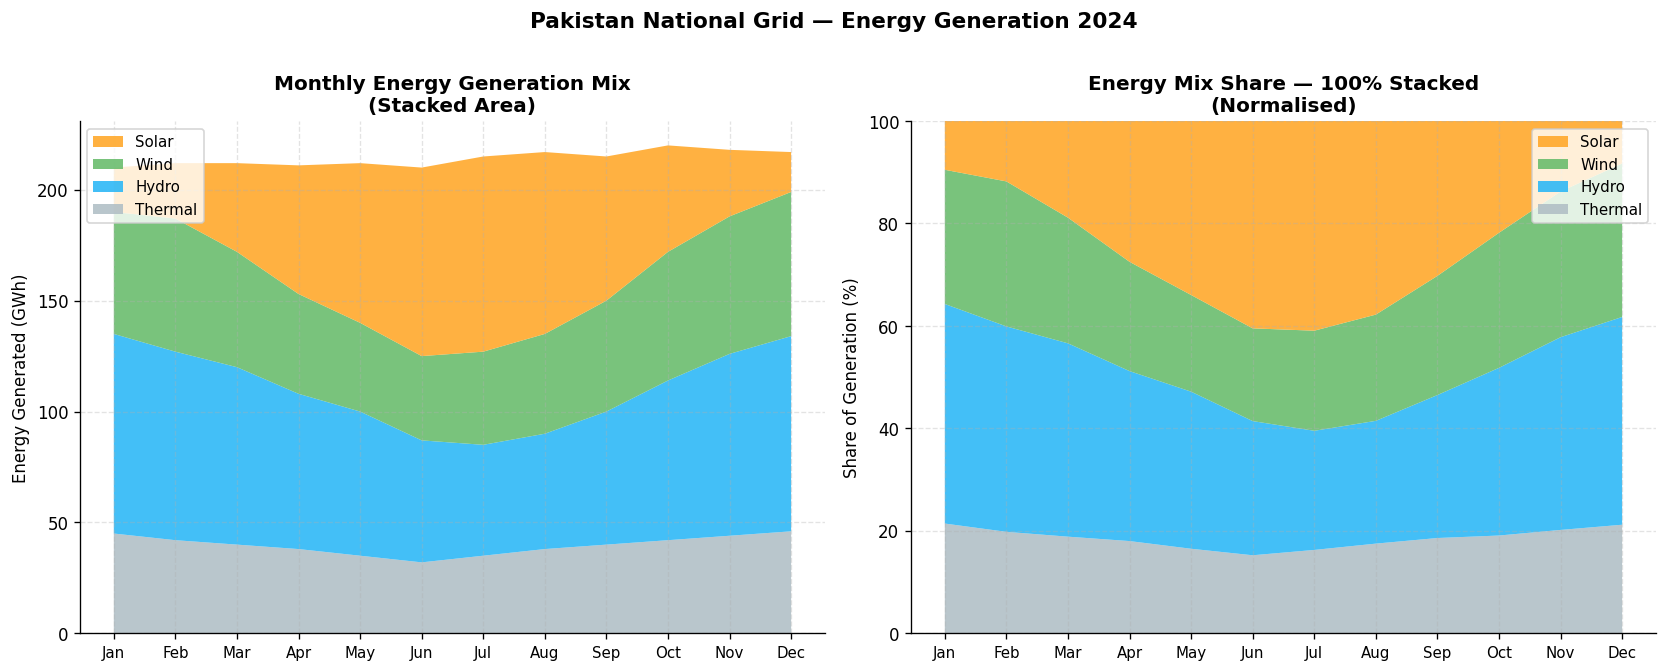

In [22]:
# ── Dataset: Energy generation by source over 12 months ────────
months = np.arange(1, 13)
solar   = [20, 25, 40, 58, 72, 85, 88, 82, 65, 48, 30, 18]   # GWh
wind    = [55, 60, 52, 45, 40, 38, 42, 45, 50, 58, 62, 65]
hydro   = [90, 85, 80, 70, 65, 55, 50, 52, 60, 72, 82, 88]
thermal = [45, 42, 40, 38, 35, 32, 35, 38, 40, 42, 44, 46]

solar_a   = np.array(solar)
wind_a    = np.array(wind)
hydro_a   = np.array(hydro)
thermal_a = np.array(thermal)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ═══════════════════════════════════════════════════════
# LEFT: Stacked Area Chart
# ═══════════════════════════════════════════════════════
# stackplot() is the dedicated stacked area function.
# It automatically computes the cumulative baselines.
ax1.stackplot(months,
              thermal_a, hydro_a, wind_a, solar_a,
              labels=['Thermal','Hydro','Wind','Solar'],
              colors=['#B0BEC5','#29B6F6','#66BB6A','#FFA726'],
              alpha=0.88)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, fontsize=9)
ax1.set_ylabel('Energy Generated (GWh)', fontsize=10)
ax1.set_title('Monthly Energy Generation Mix\n(Stacked Area)', fontweight='bold')
# legend in reverse order so it matches the visual stack
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels[::-1], loc='upper left', fontsize=9)

# ═══════════════════════════════════════════════════════
# RIGHT: Overlapping area chart (normalised to 100%)
# ═══════════════════════════════════════════════════════
# Show SHARE of each source rather than absolute values
total = solar_a + wind_a + hydro_a + thermal_a
solar_pct   = solar_a   / total * 100
wind_pct    = wind_a    / total * 100
hydro_pct   = hydro_a   / total * 100
thermal_pct = thermal_a / total * 100

ax2.stackplot(months,
              thermal_pct, hydro_pct, wind_pct, solar_pct,
              labels=['Thermal','Hydro','Wind','Solar'],
              colors=['#B0BEC5','#29B6F6','#66BB6A','#FFA726'],
              alpha=0.88)

ax2.set_xticks(months)
ax2.set_xticklabels(month_labels, fontsize=9)
ax2.set_ylabel('Share of Generation (%)', fontsize=10)
ax2.set_ylim(0, 100)
ax2.set_title('Energy Mix Share — 100% Stacked\n(Normalised)', fontweight='bold')
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2[::-1], labels2[::-1], loc='upper right', fontsize=9)

fig.suptitle('Pakistan National Grid — Energy Generation 2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<a id='dashboard'></a>
## 15. Real-World Sales Dashboard

This section ties together everything learned so far into a production-quality multi-panel dashboard. This is the kind of figure you would send to a manager or include in a business report.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


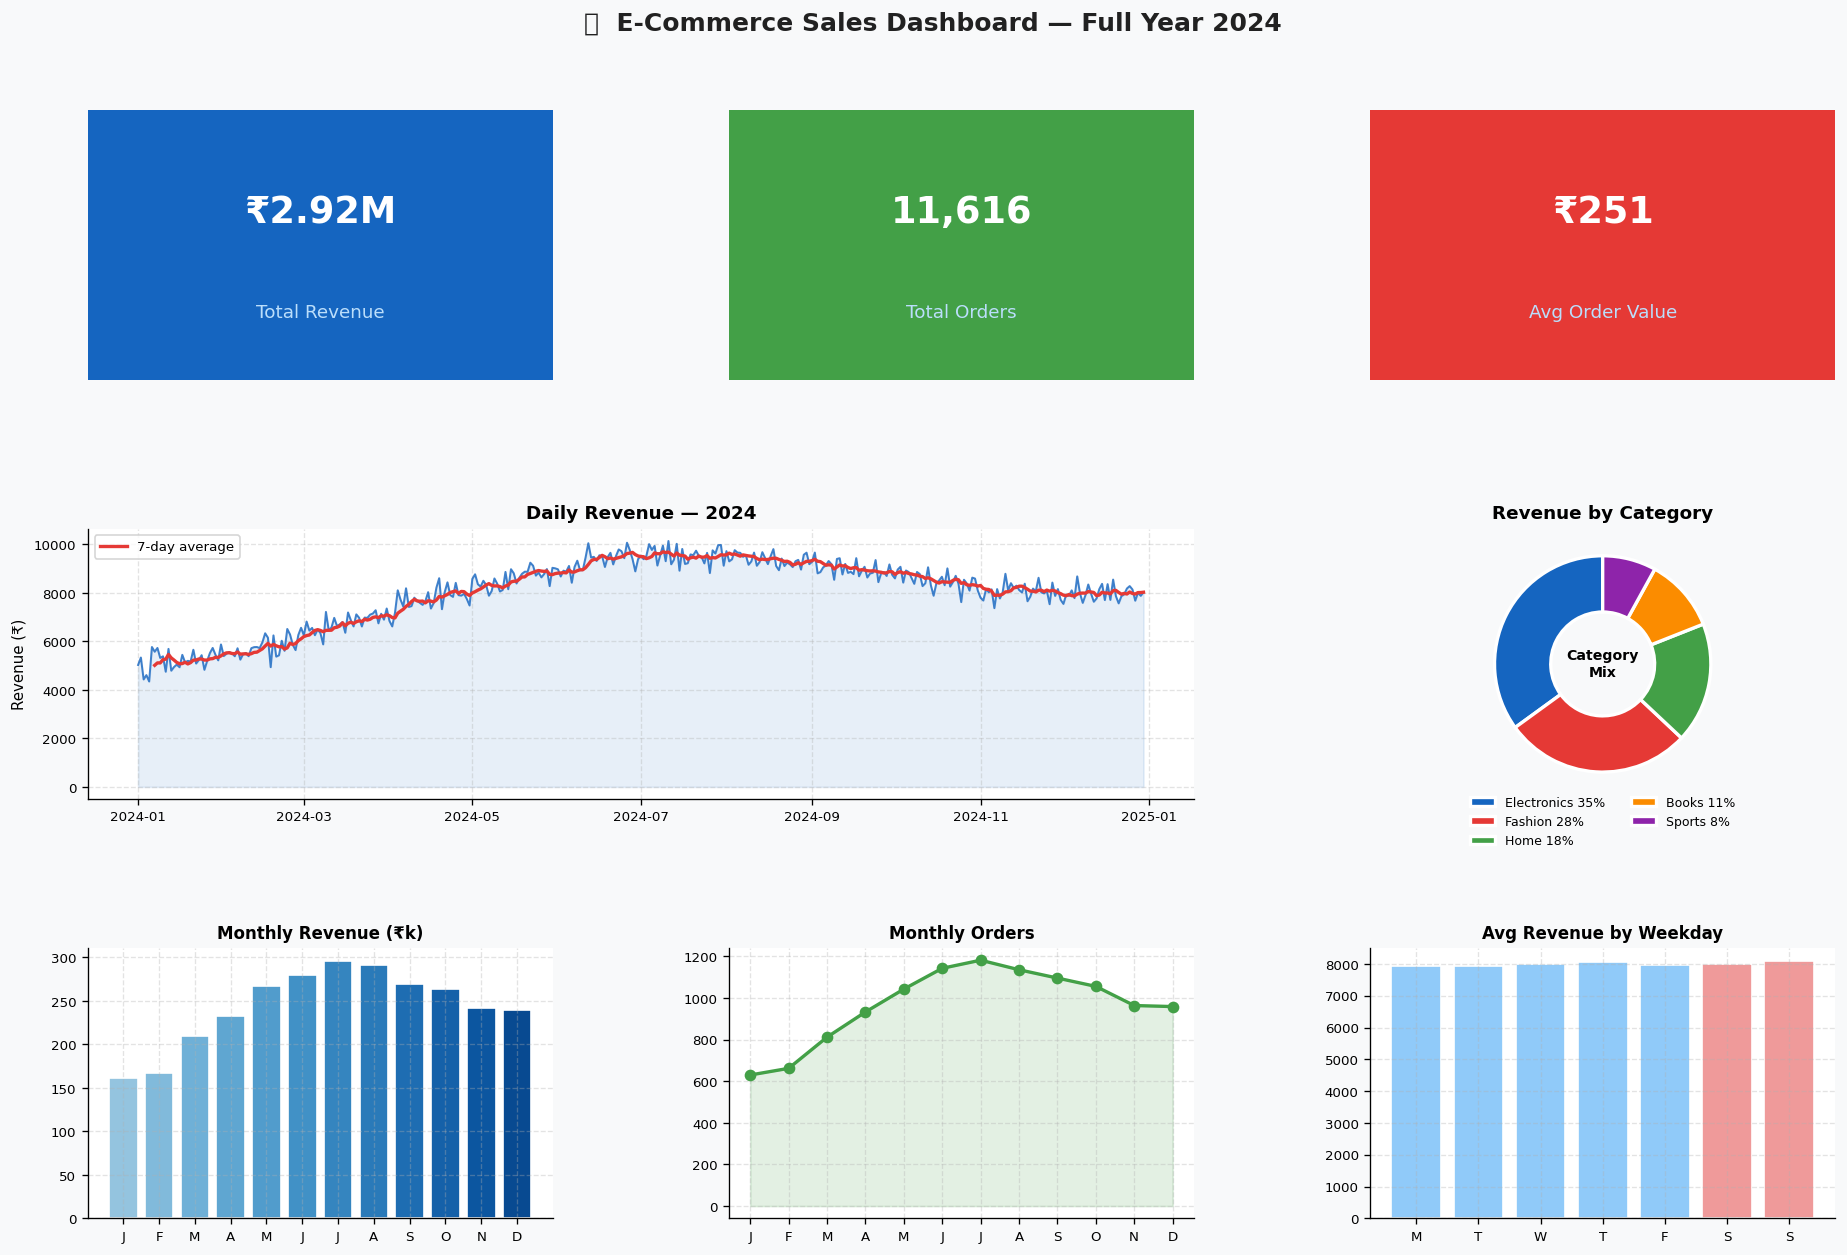

In [23]:
# ── Build a 4-panel E-commerce Sales Dashboard ────────────────
np.random.seed(8)

# ── Generate a realistic sales dataset ────────────────────
date_range = pd.date_range('2024-01-01', periods=365, freq='D')

# Base trend + seasonality + noise
trend     = np.linspace(5000, 8000, 365)
seasonal  = 1500 * np.sin(2 * np.pi * np.arange(365) / 365 - np.pi/2) + 1500
daily_rev = trend + seasonal + np.random.normal(0, 300, 365)
daily_rev = np.clip(daily_rev, 3000, 12000)

df = pd.DataFrame({
    'date':     date_range,
    'revenue':  daily_rev,
    'orders':   (daily_rev / 250 + np.random.normal(0, 3, 365)).astype(int),
})
df['month']    = df['date'].dt.month
df['week']     = df['date'].dt.isocalendar().week
df['weekday']  = df['date'].dt.day_name()

monthly_rev = df.groupby('month')['revenue'].sum() / 1000   # in thousands
monthly_ord = df.groupby('month')['orders'].sum()

categories  = ['Electronics', 'Fashion', 'Home', 'Books', 'Sports']
cat_share   = [35, 28, 18, 11, 8]
cat_colors  = ['#1565C0','#E53935','#43A047','#FB8C00','#8E24AA']

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wday_rev = df.groupby('weekday')['revenue'].mean().reindex(weekday_order)

# ── Create the dashboard ───────────────────────────────────
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#F8F9FA')   # light grey page background

gs = fig.add_gridspec(3, 3,
                      hspace=0.55, wspace=0.38,
                      top=0.90, bottom=0.06,
                      left=0.06, right=0.97)

# ── TOP ROW: 3 KPI metric cards ───────────────────────────
kpi_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
kpi_data = [
    ('Total Revenue', f'₹{daily_rev.sum()/1e6:.2f}M', '#1565C0'),
    ('Total Orders',  f'{df["orders"].sum():,}',        '#43A047'),
    ('Avg Order Value',f'₹{daily_rev.sum()/df["orders"].sum():.0f}','#E53935'),
]
for ax_k, (label, value, color) in zip(kpi_axes, kpi_data):
    ax_k.set_facecolor(color)
    ax_k.text(0.5, 0.62, value, ha='center', va='center',
              fontsize=22, fontweight='bold', color='white',
              transform=ax_k.transAxes)
    ax_k.text(0.5, 0.25, label, ha='center', va='center',
              fontsize=11, color='#BBDEFB',
              transform=ax_k.transAxes)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    for spine in ax_k.spines.values(): spine.set_visible(False)

# ── MIDDLE LEFT (spans 2 cols): Daily Revenue Line ────────
ax_line = fig.add_subplot(gs[1, 0:2])
ax_line.set_facecolor('#FFFFFF')
ax_line.plot(df['date'], df['revenue'], color='#1565C0', lw=1.2, alpha=0.8)
ax_line.fill_between(df['date'], 0, df['revenue'], alpha=0.1, color='#1565C0')
# 7-day rolling average
rolling = df['revenue'].rolling(7).mean()
ax_line.plot(df['date'], rolling, color='#E53935', lw=2, label='7-day average')
ax_line.set_title('Daily Revenue — 2024', fontweight='bold', fontsize=11)
ax_line.set_ylabel('Revenue (₹)', fontsize=9)
ax_line.legend(fontsize=8, loc='upper left')
ax_line.tick_params(axis='both', labelsize=8)

# ── MIDDLE RIGHT: Donut — Category Share ──────────────────
ax_donut = fig.add_subplot(gs[1, 2])
ax_donut.set_facecolor('#FFFFFF')
ax_donut.pie(cat_share,
             colors=cat_colors,
             startangle=90,
             wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2))
ax_donut.text(0, 0, 'Category\nMix', ha='center', va='center',
              fontsize=8.5, fontweight='bold')
ax_donut.set_title('Revenue by Category', fontweight='bold', fontsize=11)
ax_donut.legend([f'{c} {s}%' for c, s in zip(categories, cat_share)],
                loc='lower center', bbox_to_anchor=(0.5, -0.22),
                ncol=2, fontsize=7.5, frameon=False)

# ── BOTTOM LEFT: Monthly Bar ───────────────────────────────
ax_bar = fig.add_subplot(gs[2, 0])
ax_bar.set_facecolor('#FFFFFF')
bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 12))
bars = ax_bar.bar(range(1, 13), monthly_rev, color=bar_colors, edgecolor='white')
ax_bar.set_xticks(range(1, 13))
ax_bar.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'],
                        fontsize=8)
ax_bar.set_title('Monthly Revenue (₹k)', fontweight='bold', fontsize=10)
ax_bar.tick_params(axis='both', labelsize=8)

# ── BOTTOM MIDDLE: Orders by Month ────────────────────────
ax_orders = fig.add_subplot(gs[2, 1])
ax_orders.set_facecolor('#FFFFFF')
ax_orders.plot(range(1, 13), monthly_ord, color='#43A047',
               marker='o', lw=2, markersize=6)
ax_orders.fill_between(range(1, 13), 0, monthly_ord, alpha=0.15, color='#43A047')
ax_orders.set_xticks(range(1, 13))
ax_orders.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'],
                           fontsize=8)
ax_orders.set_title('Monthly Orders', fontweight='bold', fontsize=10)
ax_orders.tick_params(axis='both', labelsize=8)

# ── BOTTOM RIGHT: Avg Revenue by Weekday ─────────────────
ax_wday = fig.add_subplot(gs[2, 2])
ax_wday.set_facecolor('#FFFFFF')
wday_colors = ['#90CAF9']*5 + ['#EF9A9A']*2   # weekdays blue, weekend red
ax_wday.bar(range(7), wday_rev.values, color=wday_colors, edgecolor='white')
ax_wday.set_xticks(range(7))
ax_wday.set_xticklabels(['M','T','W','T','F','S','S'], fontsize=8)
ax_wday.set_title('Avg Revenue by Weekday', fontweight='bold', fontsize=10)
ax_wday.tick_params(axis='both', labelsize=8)

# ── Super title ───────────────────────────────────────────
fig.text(0.5, 0.96,
         '📊  E-Commerce Sales Dashboard — Full Year 2024',
         ha='center', fontsize=15, fontweight='bold', color='#212121')

plt.show()


<a id='saving'></a>
## 16. Saving Figures for Reports & Presentations

Knowing how to save figures correctly is crucial for professional work. Different formats suit different purposes.

| Format | Best for | Notes |
|--------|----------|-------|
| **PNG** | Web, slides, reports | Raster; use `dpi=150`+ |
| **SVG** | Web, scalable graphics | Vector; editable in Illustrator |
| **PDF** | Academic papers, LaTeX | Vector; perfect quality at any zoom |
| **JPG** | Photos / quick sharing | Lossy; avoid for data charts |


Figures saved to /home/claude/saved_figures/
  trig_functions.png                       148.3 KB


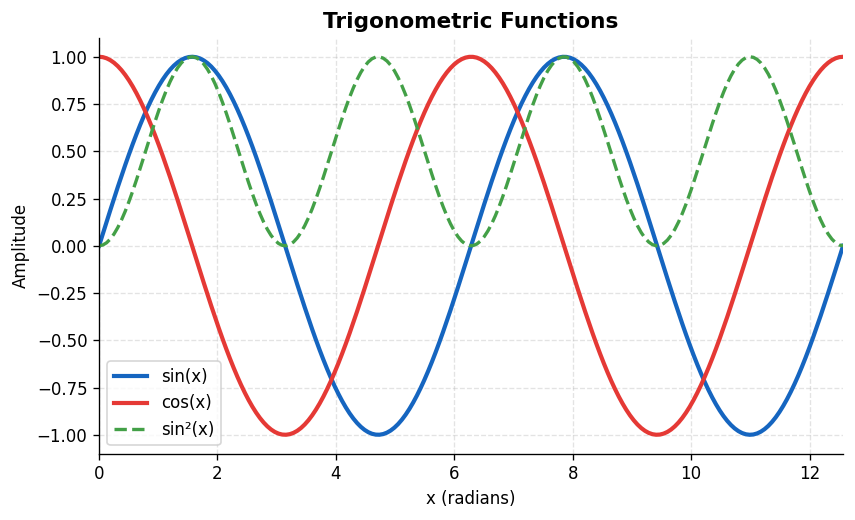

In [24]:
# ── Saving a figure: best practices ─────────────────────────
import os

# First, create a simple but clean figure to save
fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.linspace(0, 4 * np.pi, 200)
ax.plot(x, np.sin(x),   lw=2.5, label='sin(x)',   color='#1565C0')
ax.plot(x, np.cos(x),   lw=2.5, label='cos(x)',   color='#E53935')
ax.plot(x, np.sin(x)**2,lw=2,   label='sin²(x)', color='#43A047', linestyle='--')

ax.set_title('Trigonometric Functions', fontsize=13, fontweight='bold')
ax.set_xlabel('x (radians)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=10)
ax.set_xlim(0, 4*np.pi)

# ── Key parameters for savefig() ─────────────────────────
# dpi=        dots per inch (150 for screen, 300 for print)
# bbox_inches='tight'  → crops out whitespace around the figure (ALWAYS use this)
# facecolor=  background color of saved image
# transparent=True → transparent background (great for slides)
# format=     auto-detected from file extension, or specify explicitly

os.makedirs('/home/claude/saved_figures', exist_ok=True)

# Save as high-quality PNG (most common)
fig.savefig('/home/claude/saved_figures/trig_functions.png',
            dpi=180,
            bbox_inches='tight',   # remove extra whitespace — ALWAYS include
            facecolor='white')     # ensure white background (not transparent)

print("Figures saved to /home/claude/saved_figures/")

# ── Display the saved file size ────────────────────────────
for fname in os.listdir('/home/claude/saved_figures'):
    fpath = f'/home/claude/saved_figures/{fname}'
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<40} {size:.1f} KB")

plt.show()


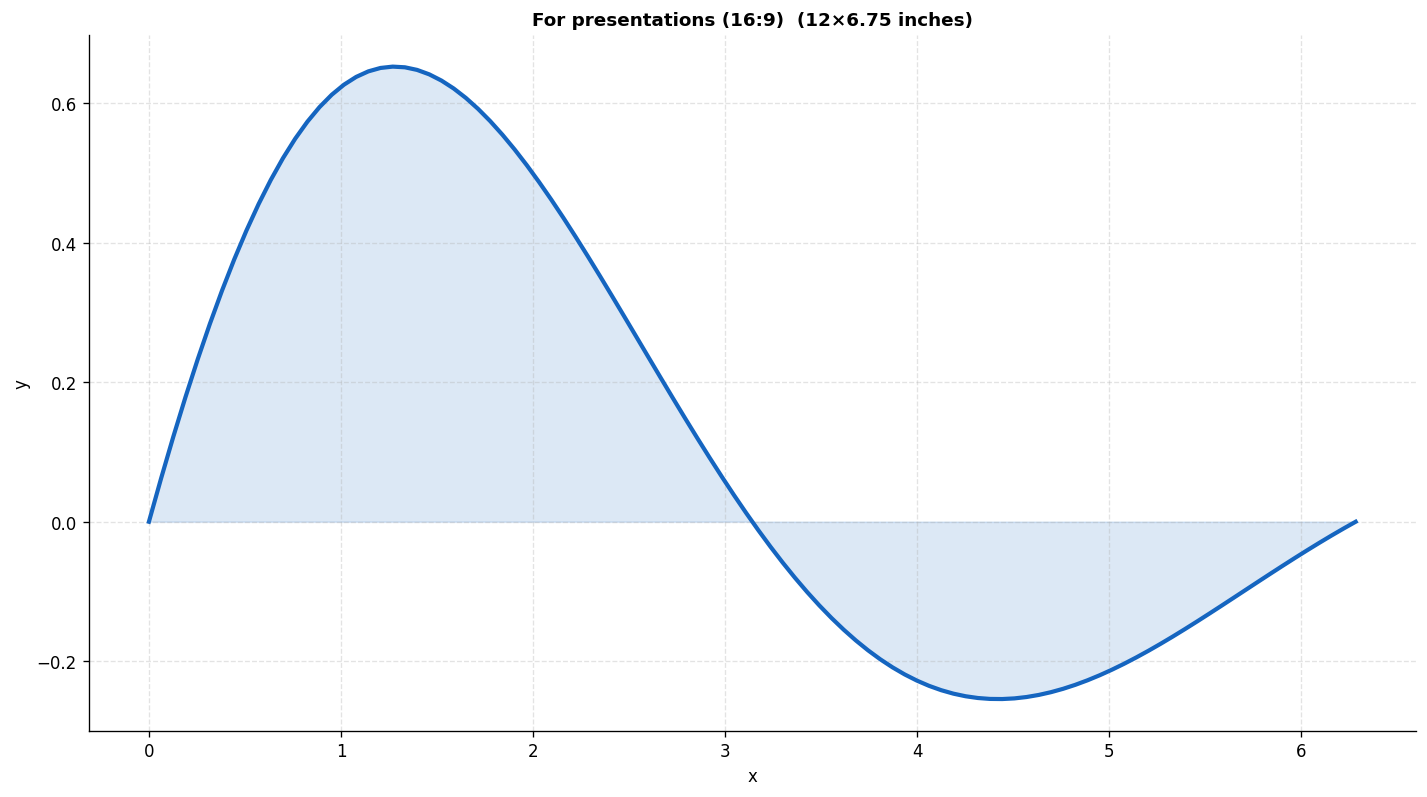

  → Figure size: 12" × 6.75"  |  Aspect ratio: 1.78


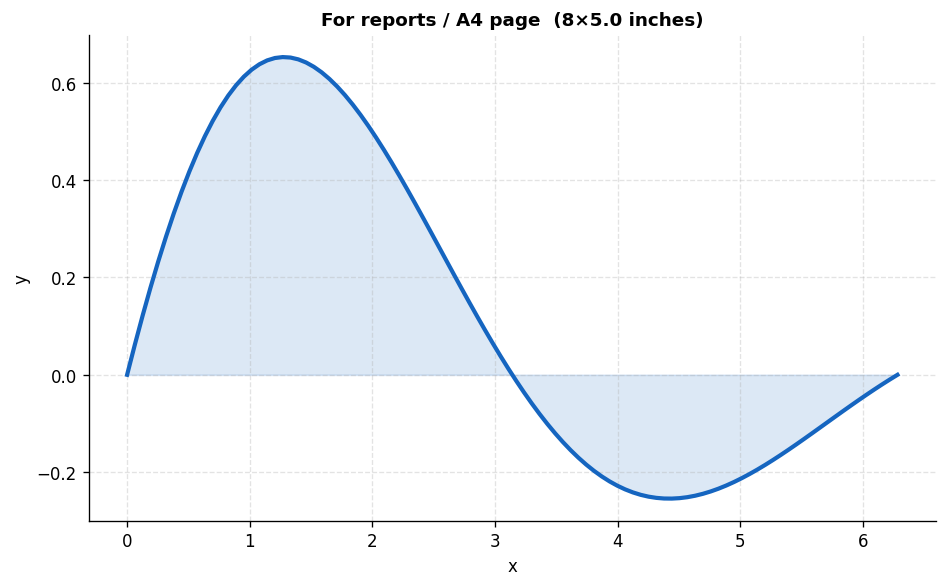

  → Figure size: 8" × 5.0"  |  Aspect ratio: 1.60


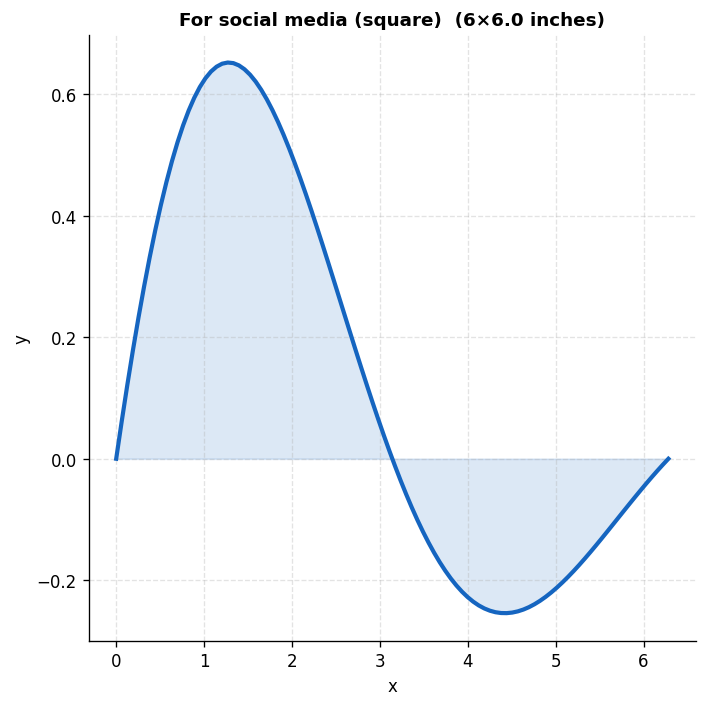

  → Figure size: 6" × 6.0"  |  Aspect ratio: 1.00


In [25]:
# ── Practical tips: figure size for different outputs ─────────
# The same data, different figure sizes for different destinations

configs = [
    ('For presentations (16:9)',    (12, 6.75)),
    ('For reports / A4 page',       (8,  5.00)),
    ('For social media (square)',   (6,  6.00)),
]

x = np.linspace(0, 2*np.pi, 100)

for title, (w, h) in configs:
    fig, ax = plt.subplots(figsize=(w, h))
    ax.plot(x, np.sin(x)*np.exp(-0.3*x),
            color='#1565C0', lw=2.5)
    ax.fill_between(x, 0, np.sin(x)*np.exp(-0.3*x), alpha=0.15, color='#1565C0')
    ax.set_title(f'{title}  ({w}×{h} inches)', fontsize=11, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()
    print(f"  → Figure size: {w}\" × {h}\"  |  Aspect ratio: {w/h:.2f}")


<a id='summary'></a>
## 17. Key Takeaways & Cheat Sheet

---

### 🏁 What You've Learned

| Concept | Key Functions / Methods |
|---------|------------------------|
| **Figure & Axes** | `plt.subplots()`, `fig.add_gridspec()`, `ax.twinx()` |
| **Line Plot** | `ax.plot()`, `ax.fill_between()` |
| **Scatter Plot** | `ax.scatter()` with `c=`, `s=`, `alpha=` |
| **Bar Chart** | `ax.bar()`, `ax.barh()`, `ax.bar_label()` |
| **Histogram** | `ax.hist()` with `bins=`, `density=` |
| **Pie / Donut** | `ax.pie()` with `wedgeprops=`, `autopct=` |
| **Box / Violin** | `ax.boxplot()`, `ax.violinplot()` |
| **Heatmap** | `ax.imshow()` with `cmap=`, `vmin=`, `vmax=` |
| **Stacked Area** | `ax.stackplot()` |
| **Annotations** | `ax.annotate()`, `ax.text()`, `ax.axhline()`, `ax.axvspan()` |
| **Styling** | `plt.style.use()`, `plt.rcParams`, `plt.cm.<name>` |
| **Saving** | `fig.savefig()` with `dpi=`, `bbox_inches='tight'` |

---

### 💡 Golden Rules

1. **Always use OO style** (`fig, ax = plt.subplots()`) — never fight with `plt.`-level state for anything non-trivial
2. **`plt.tight_layout()`** before every `plt.show()` — prevents labels from overlapping
3. **`bbox_inches='tight'`** in every `fig.savefig()` call — removes wasteful whitespace
4. **`alpha < 1`** on overlapping elements — transparency prevents occlusion
5. **Label your axes** — a chart without axis labels is incomplete
6. **Match colors to meaning** — red for loss/negative, green for gain/positive, blue for neutral
7. **Fewer is more** — resist adding every element; whitespace is visual breathing room
8. **Use `ax.bar_label()`** to auto-place value labels on bar charts (Matplotlib 3.4+)
9. **Use colormaps, not random colors** for continuous data — `plt.cm.viridis` is colorblind-safe
10. **`dpi=150` minimum** for PNG saves — lower DPI looks blurry in reports

---

### 📊 Chart Selection Guide

```
What do you want to show?
│
├── Change over time ──────────────────── Line Plot
├── Comparison across categories ──────── Bar / Horizontal Bar
├── Part-to-whole ─────────────────────── Pie / Donut / Stacked Bar
├── Distribution of values ────────────── Histogram / Box / Violin
├── Relationship between two variables ─── Scatter / Bubble
├── Correlation matrix / grid data ────── Heatmap (imshow)
└── Volume over time ──────────────────── Area / Stacked Area
```

---

### 📖 Where to Go Next

- **Official docs**: https://matplotlib.org/stable/
- **Gallery (500+ examples)**: https://matplotlib.org/stable/gallery/
- **Seaborn** (statistical charts on top of Matplotlib): https://seaborn.pydata.org
- **Plotly** (interactive charts): https://plotly.com/python/
- **Practice datasets**: https://www.kaggle.com/datasets

---
*Happy plotting! 📊*
